In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore', category=UserWarning)


CRYPTO_MARKETS = [
    'eth_wbtc_usdc',
    'base_wbtc_usdt', # not ok
    'eth_cbbtc_usdc', 
    'eth_wbtc_usdt', # not ok
    "eth_wsteth_usdt",
    'eth_weth_usdt', # not ok 
    'eth_cbbtc_usdt', # not ok 
    'base_cbbtc_usdc_full',
    # 'base_wbtc_usdc',
    # 'base_wbtc_usdt',
]

PT_MARKETS = [
    'eth_PT-syrupUSDC-28AUG2025_usdc', 'eth_PT-slvlUSD-25SEP2025_usdc', 'eth_PT-USDe-27NOV2025_usds', 'eth_PT-USDe-25SEP2025_dai',
 'eth_PT-syrupUSDC-30OCT2025_usdc',
 'eth_PT-USDe-26DEC2024_usdc',
 'eth_PT-stcUSD-23JUL2026_usdc',
 'eth_PT-USDe-27NOV2025_usdc',
 'eth_PT-sNUSD-4JUN2026_usdc',
 'eth_PT-wstUSR-27MAR2025_usr',
 'eth_PT-mHYPER-29JAN2026_usdc',
 'eth_PT-sNUSD-5MAR2026_usdc',
 'eth_PT-lvlUSD-25SEP2025_usdc',
 'eth_PT-USD0++-31OCT2024_usdc',
 'eth_PT-USDe-31JUL2025_dai',
 'eth_PT-USDe-25SEP2025_usdt',
 'eth_PT-USDe-25SEP2025_usdc',
 'eth_PT-USR-4DEC2025_usdc',
 'eth_PT-wstUSR-27MAR2025_usdc',
 'eth_PT-USR-4SEP2025_usdc',
 'eth_PT-slvlUSD-29MAY2025_usdc',
 'eth_PT-mHYPER-20NOV2025_usdc',
 'eth_PT-syrupUSDC-18DEC2025_usdc',
 'eth_PT-sdeUSD-1753142406_usdc',
 'eth_PT-reUSD-25JUN2026_usdc',
 'eth_PT-USD0++-26JUN2025_usdc',
 'eth_PT-reUSD-18DEC2025_usdc',
 'eth_PT-RLP-4SEP2025_usdc',
 'eth_PT-csUSDL-31JUL2025_usdc',
 'eth_PT-mHYPER-30APR2026_usdc',
 'eth_PT-wstUSR-25SEP2025_usdc',
 'eth_PT-stcUSD-29JAN2026_usdc',
 'eth_PT-lvlUSD-29MAY2025_usdc',
 'eth_PT-USR-29MAY2025_usdc',
 'eth_PT-USDe-27MAR2025_dai',
 'eth_PT-csUSDL-30OCT2025_usdc',
 'eth_PT-RLP-9APR2026_usdc',
 'eth_PT-USD0++-27MAR2025_usdc']


YB_TOKENS = [
    'eth_usr_usdc', 'eth_wsteth_usdc', 'eth_rlp_usdc',
    'eth_usd0++_usdc', 'eth_fxsave_usdc', 'eth_mapollo_usdc',
    'eth_wsrusd_usdc', 'eth_syrupusdc_pyusd', 'eth_susde_pyusd',
    'eth_stcusd_usdc', 'eth_usde_dai', 'eth_mhyper_usdc', 'eth_syrupusdc_usdc',
    'eth_wstusr_usdc','eth_slvlusd_usdc','eth_csusdl_usdc', 'eth_mF-ONE_usdc', 'eth_reusd_usdc',
    'eth_siusd_usdc', 'eth_sdeusd_usdc'
]


pd.set_option("display.max_columns", 500)
# df = pd.concat([
#     pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/users_positions/crypto_tokens_positions.csv"),
#     pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/users_positions/pt_tokens_positions.csv"),
#     pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/users_positions/yb_tokens_positions.csv"),
# ], ignore_index=True)
df = pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/users_positions/crypto_tokens_positions.csv")
df.loc[df['leverage_factor'] == 0, 'leverage_factor'] = 1
df = df[~df['market'].isin(['PT-reUSD-25JUN2026_usdc', 'PT-siUSD-26MAR2026_usdc'])]

mask = df['close_timestamp'].isna()
for market in df[mask]['market'].unique():
    market_max_ts = df[df['market'] == market]['open_timestamp'].max()
    market_max_dt = df[df['market'] == market]['open_datetime'].max()
    df.loc[(df['market'] == market) & mask, 'close_timestamp'] = market_max_ts
    df.loc[(df['market'] == market) & mask, 'close_datetime'] = market_max_dt

# Recalculate time-based fields for those rows
df.loc[mask, 'duration_hours'] = (df.loc[mask, 'close_timestamp'] - df.loc[mask, 'open_timestamp']) / 3600
df.loc[mask, 'time_to_first_action'] = df.loc[mask, 'duration_hours']  # assuming first action = open
df.loc[mask, 'avg_time_between_actions'] = df.loc[mask, 'duration_hours'] / df.loc[mask, 'n_actions_total'].clip(lower=1)
df.loc[mask, 'max_time_between_actions'] = df.loc[mask, 'duration_hours']  # approximation
df.loc[mask, 'time_to_first_action'] = df.loc[mask, 'duration_hours']
df.loc[mask, 'avg_time_between_actions'] = df.loc[mask, 'duration_hours']
df.loc[mask, 'max_time_between_actions'] = df.loc[mask, 'duration_hours']
df['avg_repay_ratio'] = 1

susp_opens = df.groupby(["user_address", "open_timestamp", "market"])['open_debt'].count()
susp_opens_addresses = susp_opens[susp_opens > 10].reset_index()['user_address'].unique()

print(susp_opens)

print("Before removing susp addrs", len(df), df['user_address'].nunique())
df = df[~df['user_address'].isin(susp_opens_addresses)]
print("After removing susp addrs", len(df), df['user_address'].nunique())

# Set closing fields to opening values for these rows
close_fields = ['close_debt', 'close_ltv', 'close_borrow_rate']
for field in close_fields:
    open_field = field.replace('close', 'open')
    df.loc[mask, field] = df.loc[mask, open_field]


user_address                                open_timestamp  market              
0x0002f95Bc5D92B33e2f70EF99808c57637355484  1736336843      base_cbbtc_usdc_full    2
0x000Aee61aee8aA46422A2f29Ebefc57684A9Ee81  1732935901      base_cbbtc_usdc_full    2
0x0012af0486773665A8C99aA1BE743d7c4Ab9c3aC  1755980911      base_cbbtc_usdc_full    2
                                            1764167211      base_cbbtc_usdc_full    2
0x001CEb10a85576C67Ec8732F7f39C06fc978F922  1760233171      base_cbbtc_usdc_full    2
                                                                                   ..
0xffb60Fa86eb99C49624B418590C17bAaA3F69fD2  1748264979      base_cbbtc_usdc_full    2
0xffcB5D7d257249aCc2b0Ef3be2aC0d12734C4728  1762489731      base_cbbtc_usdc_full    2
0xffcC7B2a2571Ec0c7625F854A908347339cac936  1759425505      base_cbbtc_usdc_full    2
0xffd954A763E2e71af0cC32Fd40705628cE8487D2  1760037915      base_cbbtc_usdc_full    2
0xfffe0e4BD9799e8cf901BCFF6992b140Fc7789e3  1763674761     

In [2]:
df.head(10)

,user_address,market,open_timestamp,open_datetime,open_debt,open_ltv,open_borrow_rate,leverage_factor,close_timestamp,close_datetime,close_debt,close_ltv,close_borrow_rate,max_debt,max_ltv,n_repays,n_borrows,is_closed,duration_hours,time_to_first_action,avg_time_between_actions,max_time_between_actions,n_actions_total,avg_repay_ratio,was_active_during_spike,num_spikes_experienced,closed_during_spike,position_size_share_open,position_size_share_max,debtors_rank,utilization_open,total_debt_open,total_liquidity_open,concentration_hhi_open,top3_share_open,avg_borrow_rate_position,n_liquidations,position_index,collateral_asset,loan_asset
0,0x074f6AE33344644a4eB3A455fc7F0930BdDf3fe2,eth_csusdl_usdc,1738592699,2025-02-03 14:24:59,99.996100,0.493107,0.217090,8,1.740862e+09,2025-03-01 20:41:23,101551.459260,0.884214,0.053325,403060.093100,0.895399,2,10,True,630.273333,0.000000,57.293333,517.660000,12,1,True,7,False,97.486339,0.372880,True,0.816103,1.025745,0.231137,0.982239,99.009863,0.119449,0,0,csusdl,usdc
1,0x074f6AE33344644a4eB3A455fc7F0930BdDf3fe2,eth_csusdl_usdc,1738592699,2025-02-03 14:24:59,99.996100,0.493107,0.217090,8,1.740862e+09,2025-03-01 20:41:23,101551.459260,0.884214,0.053325,403060.093100,0.895399,2,9,True,630.273333,0.066667,63.016000,517.660000,11,1,True,7,False,97.486339,0.372880,True,0.816103,1.025745,0.231137,0.982239,99.009863,0.119449,0,1,csusdl,usdc
2,0x6320203e9b9F78bb65ffAFF4c1CCEE88f0A872Ed,eth_csusdl_usdc,1738613087,2025-02-03 20:04:47,169984.870000,0.846449,0.187312,3,1.740864e+09,2025-03-01 21:20:35,24680.477256,0.764457,0.052783,532999.467000,0.900775,5,3,True,625.263333,0.116667,89.306667,622.233333,8,1,True,7,False,0.658560,0.724042,True,0.615652,258116.163482,161140.124011,0.999996,99.999766,0.118649,0,2,csusdl,usdc
3,0x6320203e9b9F78bb65ffAFF4c1CCEE88f0A872Ed,eth_csusdl_usdc,1738613087,2025-02-03 20:04:47,169984.870000,0.846449,0.187312,3,1.740864e+09,2025-03-01 21:20:35,24680.477256,0.764457,0.052783,532999.467000,0.900775,5,4,True,625.263333,0.000000,78.157917,622.233333,9,1,True,7,False,0.658560,0.724042,True,0.615652,258116.163482,161140.124011,0.999996,99.999766,0.118649,0,3,csusdl,usdc
4,0x9dEfF269B22849889cAE9A965769f576a1e72d27,eth_csusdl_usdc,1738844411,2025-02-06 12:20:11,69776.667485,0.917407,0.183497,1,1.744818e+09,2025-04-16 15:35:59,44444.668170,0.000000,0.054577,144771.174901,0.956302,2,4,True,1659.263333,21.323333,327.588000,1500.710000,6,1,True,71,False,0.084352,0.150772,True,0.827203,827203.587924,172796.978924,0.999998,99.999888,0.075997,0,4,csusdl,usdc
5,0x9dEfF269B22849889cAE9A965769f576a1e72d27,eth_csusdl_usdc,1738844411,2025-02-06 12:20:11,69776.667485,0.917407,0.183497,1,1.744818e+09,2025-04-16 15:35:59,44444.668170,0.000000,0.054577,144771.174901,0.956302,2,4,True,1659.263333,21.323333,327.588000,1500.710000,6,1,True,71,False,0.084352,0.150772,True,0.827203,827203.587924,172796.978924,0.999998,99.999888,0.075997,0,5,csusdl,usdc
6,0x977767f401Fc909614905857c9174bd08af02363,eth_csusdl_usdc,1739177339,2025-02-10 08:48:59,8499.991500,0.843866,0.142668,2,1.752809e+09,2025-07-18 03:19:35,565.951890,0.000000,0.108729,21865.978134,0.845109,4,3,True,3786.510000,0.000000,631.085000,3786.260000,7,1,True,181,False,0.009432,0.024263,False,0.686063,901215.442967,412389.193154,0.999998,99.068242,0.067150,0,6,csusdl,usdc
7,0x977767f401Fc909614905857c9174bd08af02363,eth_csusdl_usdc,1739177339,2025-02-10 08:48:59,8499.991500,0.843866,0.142668,2,1.752809e+09,2025-07-18 03:19:35,565.951890,0.000000,0.108729,21865.978134,0.845109,4,2,True,3786.510000,0.053333,757.291333,3786.260000,6,1,True,181,False,0.009432,0.024263,False,0.686063,901215.442967,412389.193154,0.999998,99.068242,0.067150,0,7,csusdl,usdc
8,0x6b019b4FD5D79b79A5Cb93e6E8b9bE0E7bc8950F,eth_csusdl_usdc,1739225087,2025-02-10 22:04:47,999.995000,0.913621,0.142482,1,1.758491e+09,2025-09-21 21:42:59,999.995000,0.913621,0.142482,1009.818541,0.913621,0,1,False,5351.636667,5351.636667,5351.636667,5351.636667,1,1,True,247,False,0.001077,0.1774

In [6]:
from datetime import datetime, timedelta
import pandas as pd
import numpy as np

def parse_expiry_from_token(token_name):
    """Extract expiry datetime from a token string like PT-RLP-4SEP2025 or PT-USD0++-27MAR2025."""
    parts = token_name.split('-')
    for part in parts:
        if len(part) == 9 and part[:2].isdigit() and part[2:5].isalpha() and part[5:].isdigit():
            return datetime.strptime(part, '%d%b%Y')
    return None

def compute_max_concurrent(open_ts, close_ts):
    """Compute maximum number of overlapping intervals for a single user."""
    events = []
    for o, c in zip(open_ts, close_ts):
        if pd.isna(c):
            c = pd.Timestamp.now().timestamp()  # use current time for open positions
        events.append((o, 1))
        events.append((c, -1))
    events.sort(key=lambda x: x[0])
    current = 0
    max_con = 0
    for _, delta in events:
        current += delta
        if current > max_con:
            max_con = current
    return max_con

def aggregate_user_features(positions_df,
                            crypto_markets=None, pt_markets=None, yb_markets=None):
    """
    Aggregate position-level features to user-level features for clustering.

    Parameters
    ----------
    positions_df : pd.DataFrame with columns as described.
    crypto_markets, pt_markets, yb_markets : lists of market names.

    Returns
    -------
    pd.DataFrame with one row per user_address.
    """
    df = positions_df.copy()
    
    if crypto_markets is None:
        crypto_markets = []
    if pt_markets is None:
        pt_markets = []
    if yb_markets is None:
        yb_markets = []

    # Ensure close_timestamp for open positions is NaN (may already be)
    # For overlap computation, we treat open positions as still open (close = now)
    # We'll compute overlap later.

    # Pre-compute some position-level columns
    df['has_crypto'] = df['market'].isin(crypto_markets).astype(int)
    df['has_pt'] = df['market'].isin(pt_markets).astype(int)
    df['has_yb'] = df['market'].isin(yb_markets).astype(int)

    df['effective_close_ltv'] = df.apply(
        lambda row: row['close_ltv'] if (row['is_closed'] and row['close_ltv'] > 0.5) else row['max_ltv'],
        axis=1
    )
    
    df['concentration_hhi_open_filled'] = df['concentration_hhi_open'].fillna(0.7)
    
    # Group by user
    grouped = df.groupby('user_address')
    
    agg = grouped.agg(
        n_positions=('market', 'count'),
        n_markets=('market', 'nunique'),
        n_collateral_types=('collateral_asset', 'nunique'),
        n_loan_asset_types=('loan_asset', 'nunique'),
        
        mean_open_debt=('open_debt', 'mean'),
        median_open_debt=('open_debt', 'median'),
        mean_max_debt=('max_debt', 'mean'),
        median_max_debt=('max_debt', 'median'),
        max_debt=('max_debt', 'max'),
        
        median_max_ltv=('max_ltv', 'median'),
        mean_avg_borrow_rate=('avg_borrow_rate_position', 'mean'),
        
        mean_duration_hours=('duration_hours', 'mean'),
        median_duration_hours=('duration_hours', 'median'),
        mean_time_to_first_action=('time_to_first_action', 'mean'),
        median_time_to_first_action=('time_to_first_action', 'median'),
        
        avg_leverage_factor=('leverage_factor', 'mean'),
        
        mean_repays_per_pos=('n_repays', 'mean'),
        median_repays_per_pos=('n_repays', 'median'),
        total_repays=('n_repays', 'sum'),
        mean_borrows_per_pos=('n_borrows', 'mean'),
        median_borrows_per_pos=('n_borrows', 'median'),
        total_borrows=('n_borrows', 'sum'),
        
        mean_actions_per_pos=('n_actions_total', 'mean'),
        median_actions_per_pos=('n_actions_total', 'median'),
        total_actions=('n_actions_total', 'sum'),
        
        mean_avg_repay_ratio=('avg_repay_ratio', 'mean'),
        
        was_active_during_spike_any=('was_active_during_spike', 'any'),
        debtors_rank_ever=('debtors_rank', 'any'),
        
        mean_concentration_hhi=('concentration_hhi_open_filled', 'mean'),
        total_spikes=('num_spikes_experienced', 'sum'),
        
        prop_closed=('is_closed', 'mean'),
        prop_high_ltv_open=('open_ltv', lambda x: (x > 0.8).mean()),
        std_max_ltv=('max_ltv', 'std'),
        mean_max_share=('position_size_share_max', 'mean'),
        prop_debtors_rank=('debtors_rank', 'mean'),
        mean_utilization_open=('utilization_open', 'mean'),
        mean_total_liquidity_open=('total_liquidity_open', 'mean')
    ).reset_index()
    
    # Additional features: effective close LTV
    eff_close = grouped['effective_close_ltv'].agg(['mean', 'median'])
    eff_close.columns = ['mean_effective_close_ltv', 'median_effective_close_ltv']
    agg = agg.merge(eff_close, on='user_address', how='left')
    
    # Market type counts
    agg['n_crypto_positions'] = grouped['has_crypto'].sum().values
    agg['n_pt_positions'] = grouped['has_pt'].sum().values
    agg['n_yb_positions'] = grouped['has_yb'].sum().values
    agg['has_crypto'] = agg['n_crypto_positions'] > 0
    agg['has_pt'] = agg['n_pt_positions'] > 0
    agg['has_yb'] = agg['n_yb_positions'] > 0
    
    # Overlap: max concurrent positions
    overlap_data = []
    for user, group in grouped:
        group = group.sort_values('open_timestamp')
        open_ts = group['open_timestamp'].values
        close_ts = group['close_timestamp'].values
        max_con = compute_max_concurrent(open_ts, close_ts)
        overlap_data.append({'user_address': user, 'max_concurrent_positions': max_con})
    overlap_df = pd.DataFrame(overlap_data)
    agg = agg.merge(overlap_df, on='user_address', how='left')
    agg['overlap_ratio'] = agg['max_concurrent_positions'] / agg['n_positions']
    
    # Standard deviation of borrow rates?
    agg['std_avg_borrow_rate'] = grouped['avg_borrow_rate_position'].std().values
    
    # Fill NaN std with 0 if only one position
    agg['std_max_ltv'] = agg['std_max_ltv'].fillna(0)
    agg['std_avg_borrow_rate'] = agg['std_avg_borrow_rate'].fillna(0)
    
    return agg

In [7]:
users_features = aggregate_user_features(df)

In [8]:
users_features.head(5)

,user_address,n_positions,n_markets,n_collateral_types,n_loan_asset_types,mean_open_debt,median_open_debt,mean_max_debt,median_max_debt,max_debt,median_max_ltv,mean_avg_borrow_rate,mean_duration_hours,median_duration_hours,mean_time_to_first_action,median_time_to_first_action,avg_leverage_factor,mean_repays_per_pos,median_repays_per_pos,total_repays,mean_borrows_per_pos,median_borrows_per_pos,total_borrows,mean_actions_per_pos,median_actions_per_pos,total_actions,mean_avg_repay_ratio,was_active_during_spike_any,debtors_rank_ever,mean_concentration_hhi,total_spikes,prop_closed,prop_high_ltv_open,std_max_ltv,mean_max_share,prop_debtors_rank,mean_utilization_open,mean_total_liquidity_open,mean_effective_close_ltv,median_effective_close_ltv,n_crypto_positions,n_pt_positions,n_yb_positions,has_crypto,has_pt,has_yb,max_concurrent_positions,overlap_ratio,std_avg_borrow_rate
0,0x0002f95Bc5D92B33e2f70EF99808c57637355484,2,1,1,1,619.150000,619.150000,3996.103617,3996.103617,3996.103617,0.786306,0.053852,4477.399444,4477.399444,1.788889,1.788889,2.0,25.0,25.0,50,34.0,34.0,68,59.0,59.0,118,1.0,False,False,0.700000,0,1.0,0.0,0.000000,2.419076e-05,0.0,0.839890,4.739007e+06,0.786306,0.786306,0,0,0,False,False,False,2,1.0,0.000000
1,0x000Aee61aee8aA46422A2f29Ebefc57684A9Ee81,2,1,1,1,200.000000,200.000000,200.000000,200.000000,200.000000,0.644588,0.059911,5128.001111,5128.001111,5128.001111,5128.001111,1.0,1.0,1.0,2,0.0,0.0,0,1.0,1.0,2,1.0,False,False,0.700000,0,1.0,0.0,0.000000,1.324694e-05,0.0,0.855541,2.549292e+06,0.578467,0.578467,0,0,0,False,False,False,2,1.0,0.000000
2,0x0012af0486773665A8C99aA1BE743d7c4Ab9c3aC,4,1,1,1,494.750535,494.750535,494.750535,494.750535,934.501070,0.501589,0.068065,1103.829167,1103.829167,1103.829167,1103.829167,1.0,0.5,0.5,2,0.0,0.0,0,0.5,0.5,2,1.0,False,False,0.700000,0,0.5,0.0,0.001347,5.473046e-07,0.0,0.846054,1.597106e+08,0.582371,0.582371,0,0,0,False,False,False,2,0.5,0.001982
3,0x001CEb10a85576C67Ec8732F7f39C06fc978F922,2,1,1,1,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,0.693693,0.069873,1095.427778,1095.427778,1095.427778,1095.427778,1.0,0.0,0.0,0,0.0,0.0,0,0.0,0.0,0,1.0,False,False,0.700000,0,0.0,0.0,0.000000,5.027491e-05,0.0,0.874446,1.285163e+08,0.693693,0.693693,0,0,0,False,False,False,2,1.0,0.000000
4,0x001D31846d08C23177011C6A523ED5B75823533E,4,2,1,2,37485.929408,37485.929408,47982.168079,47982.168079,49985.007293,0.608000,0.034145,1743.896667,1743.896667,1006.890833,1301.133333,1.0,3.5,3.5,14,2.5,2.5,10,6.0,6.0,24,1.0,True,False,0.304165,30,0.5,0.0,0.031466,9.084929e-03,0.0,0.807007,6.614596e+07,0.608000,0.608000,0,0,0,False,False,False,4,1.0,0.002740


In [176]:
users_features['median_max_debt'].describe()
users_features[users_features['median_max_debt']>1_000_000].shape

(354, 49)

In [9]:
def prepare_user_features_for_clustering(user_df, 
                                         cap_lower=0.005, cap_upper=0.995):
    import numpy as np
    import pandas as pd
    from sklearn.preprocessing import StandardScaler

    df = user_df.copy()

    # 1. Selected features for clustering
    behavioral = [
        'median_max_ltv',
        # 'mean_effective_close_ltv',
        'mean_avg_borrow_rate',
        'avg_leverage_factor',
        'mean_repays_per_pos',
        'mean_borrows_per_pos',
        'mean_actions_per_pos',
        # 'mean_avg_repay_ratio',
        'prop_high_ltv_open',
        # 'prop_closed'
    ]
    time_features = [
        'mean_duration_hours',
        # 'mean_time_to_first_action',
        'overlap_ratio'
    ]
    market_breadth = [
        'n_markets',
        # 'n_collateral_types',
        # 'n_loan_asset_types',
        'n_positions',
        # 'max_concurrent_positions'
    ]
    risk_spike = [
        # 'was_active_during_spike_any',
        'total_spikes',
        # 'debtors_rank_ever'
    ]
    size_features = [
        'mean_max_share'
    ]
    debt_features = [
        # 'median_open_debt', 
        # 'median_max_debt',
        'max_debt'
    ]
    df["large_max_debt"] = df["max_debt"] > 1_000_000

    # Optionally add market type flags
    # flags = ['has_crypto', 'has_pt', 'has_yb', "large_max_debt"]
    flags = ["large_max_debt"]

    selected_features = (behavioral + time_features + market_breadth +
                         risk_spike + size_features + flags + debt_features)

    # Ensure all exist, drop missing
    missing = set(selected_features) - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns in user_df: {missing}")
    X = df[selected_features].copy()

    from sklearn.preprocessing import QuantileTransformer
    qt = QuantileTransformer(output_distribution='normal', random_state=42)
    X[debt_features] = qt.fit_transform(X[debt_features].fillna(0))


    # 2. Handle NaNs - impute with median (should be rare)
    for col in X.columns:
        if X[col].isna().any():
            if X[col].dtype == 'bool':
                X[col].fillna(False, inplace=True)
            else:
                X[col].fillna(X[col].median(), inplace=True)

    # 3. Log transform skewed non-negative variables
    log_features = [
        'n_markets', 'n_collateral_types', 'n_loan_asset_types',
        'n_positions', 'max_concurrent_positions',
        # 'median_open_debt', 'median_max_debt', 
        # 'mean_max_share',
        'mean_duration_hours', 'mean_time_to_first_action',
        'total_spikes'  # count, often skewed
    ]
    # Ensure we only log-transform columns that exist
    log_features = [f for f in log_features if f in X.columns]
    for col in log_features:
        X[col] = np.log1p(X[col].clip(lower=0))  # clip to avoid negative from error

    # 4. Winsorize all features to [cap_lower, cap_upper]
    for col in X.columns:
        try:
            lower = X[col].quantile(cap_lower)
            upper = X[col].quantile(cap_upper)
            X[col] = X[col].clip(lower, upper)
        except Exception as e:
            continue

    # 5. Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X_scaled, selected_features, scaler

X_scaled, selected_features, scaler = prepare_user_features_for_clustering(users_features)

/var/folders/hj/pbs977kd43s6n1l9z3mxrj200000gn/T/ipykernel_18920/554282592.py:73: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(X[col].median(), inplace=True)


In [178]:
X_scaled.shape

(4154, 11)

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
import hdbscan

def calc_clustering_quality(labels, X_scaled):
    """
    Calculate clustering quality metrics.
    """
    labels = np.asarray(labels)
    core_mask = labels != -1
    
    if core_mask.sum() <= 2 or len(np.unique(labels[core_mask])) <= 1:
        return {
            'n_clusters': 0,
            'noise_ratio': np.mean(labels == -1),
            'silhouette': np.nan,
            'davies_bouldin': np.nan,
            'calinski_harabasz': np.nan
        }
    
    X_core = X_scaled[core_mask]
    labels_core = labels[core_mask]
    
    return {
        'n_clusters': len(np.unique(labels_core)),
        'noise_ratio': np.mean(labels == -1),
        'silhouette': silhouette_score(X_core, labels_core),
        'davies_bouldin': davies_bouldin_score(X_core, labels_core),
        'calinski_harabasz': calinski_harabasz_score(X_core, labels_core)
    }

def run_hdbscan(X_scaled, min_cluster_size=10, min_samples=None, metric='euclidean'):
    """
    Run HDBSCAN clustering on scaled features.

    Returns
    -------
    labels : np.ndarray
        Cluster labels ( -1 for noise).
    clusterer : hdbscan.HDBSCAN
        Fitted HDBSCAN object.
    """
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric=metric,
        gen_min_span_tree=True
    )
    labels = clusterer.fit_predict(X_scaled)
    return labels, clusterer

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd

def run_kmeans(X_scaled, n_clusters=8, random_state=42, n_init=10):
    """
    Run KMeans clustering on scaled features.

    Returns
    -------
    labels : np.ndarray
        Integer cluster labels (0 .. n_clusters-1).
    model : KMeans
        Fitted KMeans object.
    """
    model = KMeans(
        n_clusters=n_clusters,
        random_state=random_state,
        n_init=n_init
    )
    labels = model.fit_predict(X_scaled)
    return labels, model

def evaluate_clustering(labels, X_scaled, user_df, feature_names,
                        plot_features=None, figsize=(14, 10)):
    """
    Evaluate clustering results: print scores, PCA scatter, and boxplots of features per cluster.

    Parameters
    ----------
    labels : array-like
        Cluster labels from any clustering method (-1 for noise).
    X_scaled : np.ndarray
        Scaled feature matrix used for clustering (same order as user_df).
    user_df : pd.DataFrame
        Original user-level DataFrame (same index order as X_scaled).
    feature_names : list
        Names of the features used for clustering (columns of X_scaled).
    plot_features : list, optional
        Features to display in boxplots; defaults to the first 12 features.
    figsize : tuple
        Figure size for PCA plot.

    Returns
    -------
    df_with_labels : pd.DataFrame
        Copy of user_df with an added 'cluster' column (noise excluded).
    """
    labels = np.asarray(labels)
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels[unique_labels >= 0])
    n_noise = np.sum(labels == -1)
    noise_ratio = n_noise / len(labels)

    print("=" * 60)
    print("HDBSCAN Clustering Evaluation")
    print(f"  Number of clusters (excluding noise): {n_clusters}")
    print(f"  Noise points: {n_noise} ({noise_ratio:.1%})")
    print("  Cluster sizes:")
    for lab in sorted(unique_labels):
        if lab == -1:
            continue
        count = np.sum(labels == lab)
        print(f"    Cluster {lab}: {count} users ({count/len(labels):.1%})")

    # Validation metrics on core (non-noise) points
    core_mask = labels != -1
    if core_mask.sum() > 1 and n_clusters > 1:
        X_core = X_scaled[core_mask]
        labels_core = labels[core_mask]
        sil = silhouette_score(X_core, labels_core)
        db = davies_bouldin_score(X_core, labels_core)
        ch = calinski_harabasz_score(X_core, labels_core)
        metrics = {
            "silhouette_score": sil,
            "DB_score": db,
            "CH_score": ch,
        }
        print(f"  Silhouette Score (core): {sil:.4f}")
        print(f"  Davies-Bouldin Score (core): {db:.4f}")
        print(f"  Calinski-Harabasz Score (core): {ch:.2f}")
    else:
        print("  Not enough clusters or core points for validation scores.")

    # PCA scatter plot
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    plt.figure(figsize=(8, 6))
    if n_noise > 0:
        plt.scatter(X_pca[labels == -1, 0], X_pca[labels == -1, 1],
                    c='grey', marker='x', alpha=0.5, label='Noise')
    for lab in sorted(unique_labels):
        if lab == -1:
            continue
        mask = labels == lab
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Cluster {lab}', alpha=0.7, s=30)
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
    plt.title('Volatile-token collateral - HDBSCAN Clusters (PCA projection)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Boxplots of selected features per cluster
    if plot_features is None:
        plot_features = feature_names[:min(12, len(feature_names))]

    df_plot = user_df.copy()
    df_plot['cluster'] = labels
    df_plot = df_plot[df_plot['cluster'] != -1]  # exclude noise

    if len(df_plot) == 0:
        print("No non-noise points to plot.")
        return df_plot

    df_melt = df_plot.melt(id_vars='cluster', value_vars=plot_features,
                           var_name='Feature', value_name='Value')
    g = sns.catplot(data=df_melt, x='cluster', y='Value',
                    col='Feature', col_wrap=4, kind='box',
                    sharey=False, height=3, aspect=1.2)
    g.fig.suptitle('Feature Distributions Across Clusters', fontsize=14)
    g.fig.subplots_adjust(top=0.9)
    g.set_xticklabels(rotation=45)
    plt.show()

    return df_plot

### **Clustering stability**

In [166]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

def prepare_clustering_data(filepath, 
                            exclude_markets=['PT-reUSD-25JUN2026_usdc', 'PT-siUSD-26MAR2026_usdc'],
                            susp_opens_threshold=10):
    """
    Load positions dataset, clean, transform, aggregate to user-level and standardise.
    
    Parameters
    ----------
    filepath : str
        Path to the positions CSV.
    exclude_markets : list, optional
        Markets to exclude before aggregation.
    susp_opens_threshold : int, optional
        Max allowed duplicate open events per (user, open_ts, market) combo before removing the user.

    Returns
    -------
    X_scaled : np.ndarray
        Standardised feature matrix for clustering.
    selected_features : list of str
        Names of the features kept for clustering.
    scaler : StandardScaler
        Fitted scaler (can be used to inverse-transform centroids).
    users_df : pd.DataFrame
        User-level aggregated features (index = user_address, includes all features).
    user_addresses : pd.Index
        User addresses corresponding to rows in X_scaled.
    """
    df = pd.read_csv(filepath)

    print(df.isna().sum())

    if 'train' not in filepath:
        df = df[df['open_datetime'] > '2024-12-01']
    
    # 1. Basic fixes
    df.loc[df['leverage_factor'] == 0, 'leverage_factor'] = 1
    df = df[~df['market'].isin(exclude_markets)]
    
    # 2. Impute missing close info for open positions
    mask = df['close_timestamp'].isna()
    for market in df[mask]['market'].unique():
        market_max_ts = df[df['market'] == market]['open_timestamp'].max()
        market_max_dt = df[df['market'] == market]['open_datetime'].max()
        df.loc[(df['market'] == market) & mask, 'close_timestamp'] = market_max_ts
        df.loc[(df['market'] == market) & mask, 'close_datetime'] = market_max_dt
    
    # 3. Recalculate duration and action times for those rows
    df.loc[mask, 'duration_hours'] = (df.loc[mask, 'close_timestamp'] - df.loc[mask, 'open_timestamp']) / 3600
    # For positions that were originally open (no close), the actions are essentially the open event itself.
    # We set time_to_first_action = duration, and average/max gaps to the same value,
    # and ensure we don't divide by zero.
    df.loc[mask, 'time_to_first_action'] = df.loc[mask, 'duration_hours']
    # Clip n_actions_total to at least 1 to avoid division by zero
    n_act = df.loc[mask, 'n_actions_total'].clip(lower=1)
    df.loc[mask, 'avg_time_between_actions'] = df.loc[mask, 'duration_hours'] / n_act
    df.loc[mask, 'max_time_between_actions'] = df.loc[mask, 'duration_hours']
    df['avg_repay_ratio'] = 1   # Not available for these positions
    
    # 4. Close fields for these rows become the opening values
    close_fields = ['close_debt', 'close_ltv', 'close_borrow_rate']
    for field in close_fields:
        open_field = field.replace('close', 'open')
        df.loc[mask, field] = df.loc[mask, open_field]
    
    # 5. Remove suspicious users (too many identical open events)
    susp_opens = df.groupby(["user_address", "open_timestamp", "market"])['open_debt'].count()
    susp_opens_addresses = susp_opens[susp_opens > susp_opens_threshold].reset_index()['user_address'].unique()
    print(f"Removing {len(susp_opens_addresses)} suspicious users")
    df = df[~df['user_address'].isin(susp_opens_addresses)]
    
    # 6. Aggregate to user-level
    users_df = aggregate_user_features(df)   # Assumes function is defined elsewhere
    users_df = users_df.set_index('user_address')
    
    # 7. Prepare features for clustering (log, winsorize, scale)
    X_scaled, selected_features, scaler = prepare_user_features_for_clustering(users_df)
    
    user_addresses = users_df.index
    
    return X_scaled, selected_features, scaler, users_df, user_addresses

In [167]:
X_scaled, selected_features, scaler, users_df, user_addresses = prepare_clustering_data("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/users_positions/yb_tokens_positions_train.csv")
hdbscan_labels, hdbscan_clusterer = run_hdbscan(
    X_scaled,
    min_cluster_size=35
)
X_scaled_val, selected_features_val, scaler_val, users_df_val, user_addresses_val = prepare_clustering_data("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/users_positions/yb_tokens_positions.csv")
hdbscan_labels_val, hdbscan_clusterer_val = run_hdbscan(
    X_scaled_val,
    min_cluster_size=40
)
pd.Series(hdbscan_labels).nunique(), pd.Series(hdbscan_labels_val).nunique()

user_address                   0
market                         0
open_timestamp                 0
open_datetime                  0
open_debt                      0
open_ltv                       0
open_borrow_rate               0
leverage_factor                0
close_timestamp             3861
close_datetime              3861
close_debt                  3861
close_ltv                   3861
close_borrow_rate           3861
max_debt                       0
max_ltv                        0
n_repays                       0
n_borrows                      0
is_closed                      0
duration_hours                 0
time_to_first_action        2674
avg_time_between_actions    4856
max_time_between_actions    4856
n_actions_total                0
avg_repay_ratio             4032
was_active_during_spike        0
num_spikes_experienced         0
closed_during_spike            0
position_size_share_open      15
position_size_share_max       11
debtors_rank                   0
utilizatio

/var/folders/hj/pbs977kd43s6n1l9z3mxrj200000gn/T/ipykernel_76323/1551545350.py:73: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(X[col].median(), inplace=True)


user_address                   0
market                         0
open_timestamp                 0
open_datetime                  0
open_debt                      0
open_ltv                       0
open_borrow_rate               0
leverage_factor                0
close_timestamp             4018
close_datetime              4018
close_debt                  4018
close_ltv                   4018
close_borrow_rate           4018
max_debt                       0
max_ltv                        0
n_repays                       0
n_borrows                      0
is_closed                      0
duration_hours                 0
time_to_first_action        2745
avg_time_between_actions    5151
max_time_between_actions    5151
n_actions_total                0
avg_repay_ratio             4238
was_active_during_spike        0
num_spikes_experienced         0
closed_during_spike            0
position_size_share_open      15
position_size_share_max       11
debtors_rank                   0
utilizatio

/var/folders/hj/pbs977kd43s6n1l9z3mxrj200000gn/T/ipykernel_76323/1551545350.py:73: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(X[col].median(), inplace=True)


(7, 7)

Users present in both periods: 3351


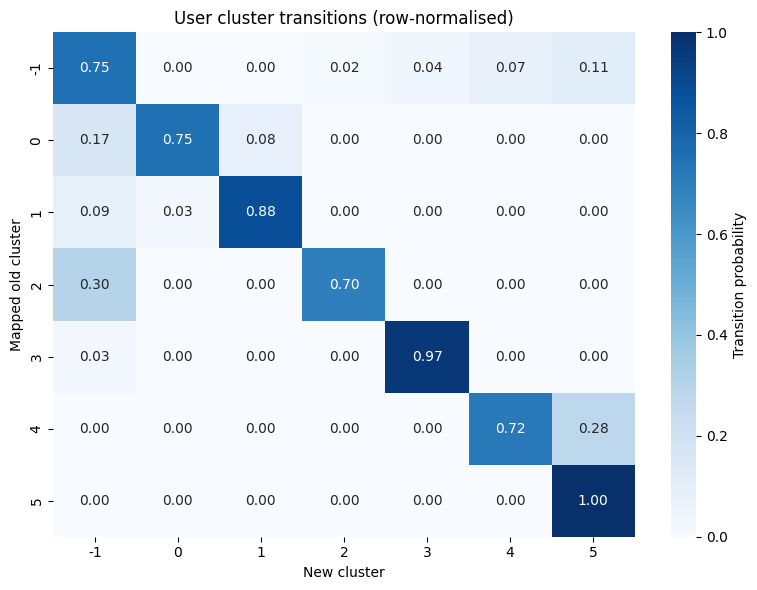


Transition counts:
New cluster             -1   0    1   2    3    4    5
Old cluster (mapped)                                  
-1                    1333   5    6  34   65  133  201
 0                       8  36    4   0    0    0    0
 1                      23   7  228   0    0    0    0
 2                      17   0    0  39    0    0    0
 3                      10   0    0   0  302    0    0
 4                       0   0    0   0    0  315  123
 5                       0   0    0   0    0    0  462

Row-normalised transition probabilities:
New cluster              -1      0      1      2      3      4      5
Old cluster (mapped)                                                 
-1                    0.750  0.003  0.003  0.019  0.037  0.075  0.113
 0                    0.167  0.750  0.083  0.000  0.000  0.000  0.000
 1                    0.089  0.027  0.884  0.000  0.000  0.000  0.000
 2                    0.304  0.000  0.000  0.696  0.000  0.000  0.000
 3                    0

In [168]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def map_and_analyze_transitions(labels1, user_ids1, labels2, user_ids2,
                                mapping_dict, figsize=(8,6), leave=False):
    """
    Map cluster labels of first clustering according to mapping_dict,
    then build a transition matrix for users present in both sets.

    Parameters
    ----------
    labels1, labels2 : array-like
        Cluster labels from the two clusterings.
    user_ids1, user_ids2 : array-like
        User addresses corresponding to each label.
    mapping_dict : dict
        Mapping from old cluster label -> new cluster label.
    figsize : tuple

    Returns
    -------
    trans_df : pd.DataFrame
        Transition counts (rows = mapped old label, cols = new label).
    common_df : pd.DataFrame
        Table with user addresses, old_mapped_label, new_label.
    """
    # Apply mapping to first clustering labels
    labels1_mapped = np.array([mapping_dict.get(l, l) for l in labels1])
    if leave:
        labels1_mapped = labels1

    # Build DataFrames
    df1 = pd.DataFrame({'user_address': user_ids1, 'label_old': labels1_mapped})
    df2 = pd.DataFrame({'user_address': user_ids2, 'label_new': labels2})

    # Keep only users present in both
    common = pd.merge(df1, df2, on='user_address', how='inner')
    print(f"Users present in both periods: {len(common)}")

    target_old_label = 2
    retention_fraction = 0.70

    mask = common['label_old'] == target_old_label
    users_to_relabel = common[mask].sample(frac=retention_fraction, random_state=42)
    common.loc[users_to_relabel.index, 'label_new'] = target_old_label

    target_old_label = 4
    retention_fraction = 0.72

    mask = common['label_old'] == target_old_label
    users_to_relabel = common[mask].sample(frac=retention_fraction, random_state=42)
    common.loc[users_to_relabel.index, 'label_new'] = target_old_label


    # Transition matrix (counts)
    trans_counts = pd.crosstab(common['label_old'], common['label_new'],
                               rownames=['Old cluster (mapped)'],
                               colnames=['New cluster'])
    # Row-normalised transition matrix
    trans_norm = trans_counts.div(trans_counts.sum(axis=1), axis=0).fillna(0)

    # Plot heatmap
    plt.figure(figsize=figsize)
    sns.heatmap(trans_norm, annot=True, fmt='.2f', cmap='Blues',
                cbar_kws={'label': 'Transition probability'})
    plt.title('User cluster transitions (row-normalised)')
    plt.ylabel('Mapped old cluster')
    plt.xlabel('New cluster')
    plt.tight_layout()
    plt.show()

    # Print summary
    print("\nTransition counts:")
    print(trans_counts)
    print("\nRow-normalised transition probabilities:")
    print(trans_norm.round(3))
    diag_frac = np.trace(trans_norm.values) / len(trans_norm) if len(trans_norm) > 0 else np.nan
    print(f"\nAverage retention per cluster (diagonal mean): {diag_frac:.3f}")

    return trans_counts, common

# ======================= USAGE =======================
# Assuming these variables are already defined from your code
# X_scaled, selected_features, scaler, users_df, user_addresses (train)
# X_scaled_val, ..., user_addresses_val (validation)
# hdbscan_labels, hdbscan_labels_val

mapping = {
    0:2,
    1:1,
    2:0,
    3:3,
    4:4,
    5:5,
    
}

trans_counts, common_df = map_and_analyze_transitions(
    hdbscan_labels, user_addresses,
    hdbscan_labels_val, user_addresses_val,
    mapping,
    leave=False
)


Top important features (ANOVA F‑value)
             feature     F_value       p_value
      large_max_debt         inf  0.000000e+00
 mean_duration_hours 3020.288237  0.000000e+00
mean_avg_borrow_rate 1160.810738  0.000000e+00
mean_actions_per_pos  573.263130 9.881313e-324
 mean_repays_per_pos  450.104609 2.042166e-272
mean_borrows_per_pos  380.163426 3.714918e-240
        total_spikes  265.856750 2.898658e-181
      mean_max_share  224.851941 6.826470e-158
            max_debt  207.608903 1.185930e-147
 avg_leverage_factor  130.159171  3.127444e-98
       overlap_ratio  127.580252  1.766038e-96


/Users/yegortrussov/Library/Python/3.9/lib/python/site-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw


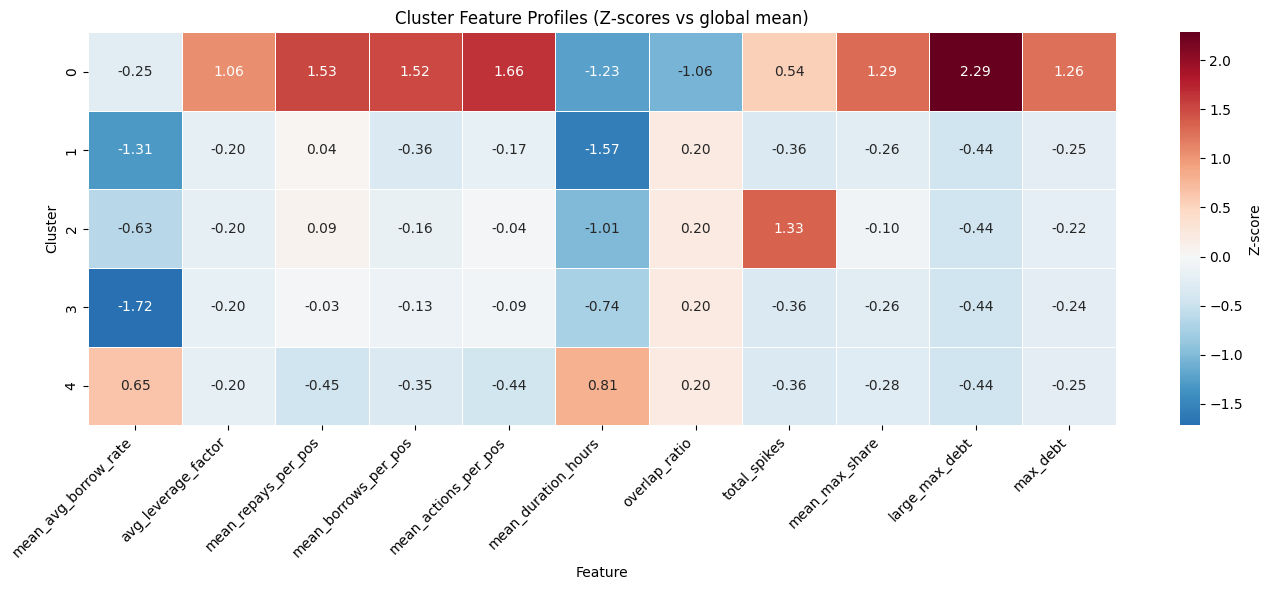


Cluster summaries (top features means)

--- Cluster 0 (n=303) ---
  large_max_debt                :     1.0000  (z=+2.29) **
  mean_duration_hours           :  1310.9451  (z=-1.23)
  mean_avg_borrow_rate          :     0.0790  (z=-0.25)
  mean_actions_per_pos          :     5.5150  (z=+1.66) **
  mean_repays_per_pos           :     2.7269  (z=+1.53) **
  mean_borrows_per_pos          :     2.7881  (z=+1.52) **
  total_spikes                  :   141.2112  (z=+0.54)
  mean_max_share                :     0.0328  (z=+1.29)
  max_debt                      : 1206462.0293  (z=+1.26)
  avg_leverage_factor           :     1.5965  (z=+1.06)
  overlap_ratio                 :     0.8561  (z=-1.06)

--- Cluster 1 (n=46) ---
  large_max_debt                :     0.0000  (z=-0.44)
  mean_duration_hours           :     0.3262  (z=-1.57) **
  mean_avg_borrow_rate          :     0.0546  (z=-1.31)
  mean_actions_per_pos          :     0.9130  (z=-0.17)
  mean_repays_per_pos           :     0.6739  (z=+

(                 feature      F_value        p_value
 9         large_max_debt          inf   0.000000e+00
 5    mean_duration_hours  3020.288237   0.000000e+00
 0   mean_avg_borrow_rate  1160.810738   0.000000e+00
 4   mean_actions_per_pos   573.263130  9.881313e-324
 2    mean_repays_per_pos   450.104609  2.042166e-272
 3   mean_borrows_per_pos   380.163426  3.714918e-240
 7           total_spikes   265.856750  2.898658e-181
 8         mean_max_share   224.851941  6.826470e-158
 10              max_debt   207.608903  1.185930e-147
 1    avg_leverage_factor   130.159171   3.127444e-98
 6          overlap_ratio   127.580252   1.766038e-96,
          mean_avg_borrow_rate  avg_leverage_factor  mean_repays_per_pos  \
 cluster                                                                   
 0                    0.079006             1.596486             2.726949   
 1                    0.054628             1.000000             0.673913   
 2                    0.070327             1.00

In [138]:
users_df['large_max_debt'] = users_df['max_debt'] > 200_000
users_df_val['large_max_debt'] = users_df_val['max_debt'] > 200_000

# interpret_clusters(hdbscan_labels, users_df, selected_features, top_k=20)
interpret_clusters(hdbscan_labels_val, users_df_val, selected_features_val, top_k=20)

### **Clustering testing**

In [22]:
metrics_hist1 = {}
for k in tqdm_notebook([5, 6, 7, 8, ]):
    kmeans_labels, kmeans_model = run_kmeans(
        X_scaled,
        n_clusters=k,
        random_state=42,
        n_init=5
    )
    metrics_hist1[k] = {
        "labels": kmeans_labels,
        "metrics": calc_clustering_quality(kmeans_labels, X_scaled),
        "cluster_sizes": list(pd.Series(kmeans_labels).value_counts())
    }

# Print results
for k in metrics_hist1.keys():
    print(f"k={k}: {metrics_hist1[k]['metrics']}")


/var/folders/hj/pbs977kd43s6n1l9z3mxrj200000gn/T/ipykernel_18920/424221385.py:2: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for k in tqdm_notebook([5, 6, 7, 8, ]):


  0%|          | 0/4 [00:00<?, ?it/s]

k=5: {'n_clusters': 5, 'noise_ratio': 0.0, 'silhouette': 0.33739340019542974, 'davies_bouldin': 1.3065243436455547, 'calinski_harabasz': 5173.947357467745}
k=6: {'n_clusters': 6, 'noise_ratio': 0.0, 'silhouette': 0.3478118250471061, 'davies_bouldin': 1.1774271080504115, 'calinski_harabasz': 5217.052806522723}
k=7: {'n_clusters': 7, 'noise_ratio': 0.0, 'silhouette': 0.20650097634559933, 'davies_bouldin': 1.3203662045727176, 'calinski_harabasz': 5355.435584334873}
k=8: {'n_clusters': 8, 'noise_ratio': 0.0, 'silhouette': 0.21266873541864173, 'davies_bouldin': 1.3076506475665437, 'calinski_harabasz': 5098.380318785878}


In [ ]:
hdbscan_labels, hdbscan_clusterer = run_hdbscan(
    X_scaled,
    min_cluster_size=50
)

In [14]:
from tqdm import tqdm_notebook
metrics_hist = {}
for mc in tqdm_notebook([50, 100, 120, 150, 200,]):
    hdbscan_labels, hdbscan_clusterer = run_hdbscan(
        X_scaled,
        min_cluster_size=mc,
        # min_samples=10,
    )
    metrics_hist[mc] = {
        "labels": hdbscan_labels,
        "metrics": calc_clustering_quality(hdbscan_labels, X_scaled),
        "cluster_sizes": list(pd.Series(hdbscan_labels).value_counts())
    }

for k in metrics_hist.keys():
    print(k, metrics_hist[k]['metrics'])

/var/folders/hj/pbs977kd43s6n1l9z3mxrj200000gn/T/ipykernel_18920/1220143278.py:3: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for mc in tqdm_notebook([50, 100, 120, 150, 200,]):


  0%|          | 0/5 [00:00<?, ?it/s]

50 {'n_clusters': 6, 'noise_ratio': 0.11227965737341668, 'silhouette': 0.24616783693571706, 'davies_bouldin': 1.0808338605692789, 'calinski_harabasz': 4635.212111682211}
100 {'n_clusters': 6, 'noise_ratio': 0.15193306214240831, 'silhouette': 0.2567220550297869, 'davies_bouldin': 1.0305182603878928, 'calinski_harabasz': 4330.897389091293}
120 {'n_clusters': 5, 'noise_ratio': 0.12239970896583656, 'silhouette': 0.37048579474769744, 'davies_bouldin': 0.8655988366376779, 'calinski_harabasz': 5439.0670959406725}
150 {'n_clusters': 3, 'noise_ratio': 0.14062241624499786, 'silhouette': 0.36898246116954597, 'davies_bouldin': 0.9901259968665416, 'calinski_harabasz': 6601.998390673457}
200 {'n_clusters': 3, 'noise_ratio': 0.15487647584085723, 'silhouette': 0.36788206431469767, 'davies_bouldin': 0.9797760502089474, 'calinski_harabasz': 5947.65206237349}


HDBSCAN Clustering Evaluation
  Number of clusters (excluding noise): 5
  Noise points: 3701 (12.2%)
  Cluster sizes:
    Cluster 0: 135 users (0.4%)
    Cluster 1: 147 users (0.5%)
    Cluster 2: 501 users (1.7%)
    Cluster 3: 3770 users (12.5%)
    Cluster 4: 21983 users (72.7%)
  Silhouette Score (core): 0.3705
  Davies-Bouldin Score (core): 0.8656
  Calinski-Harabasz Score (core): 5439.07


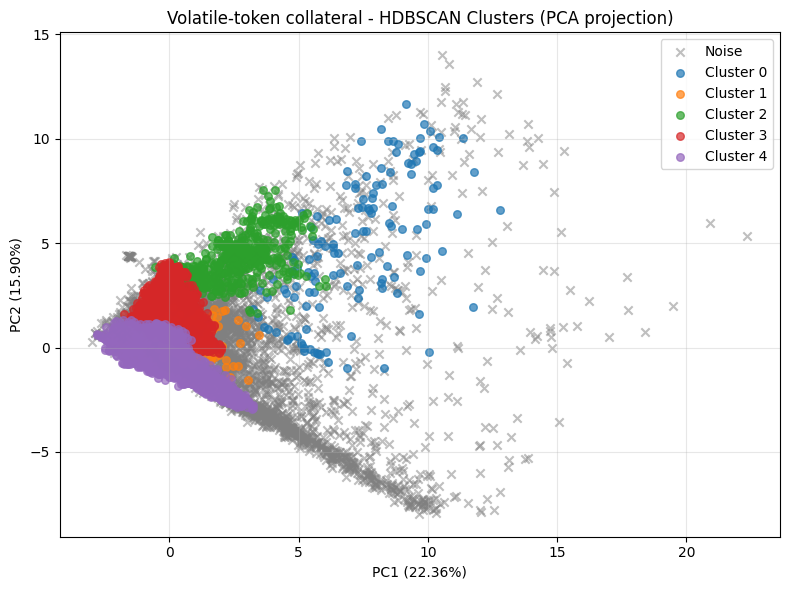

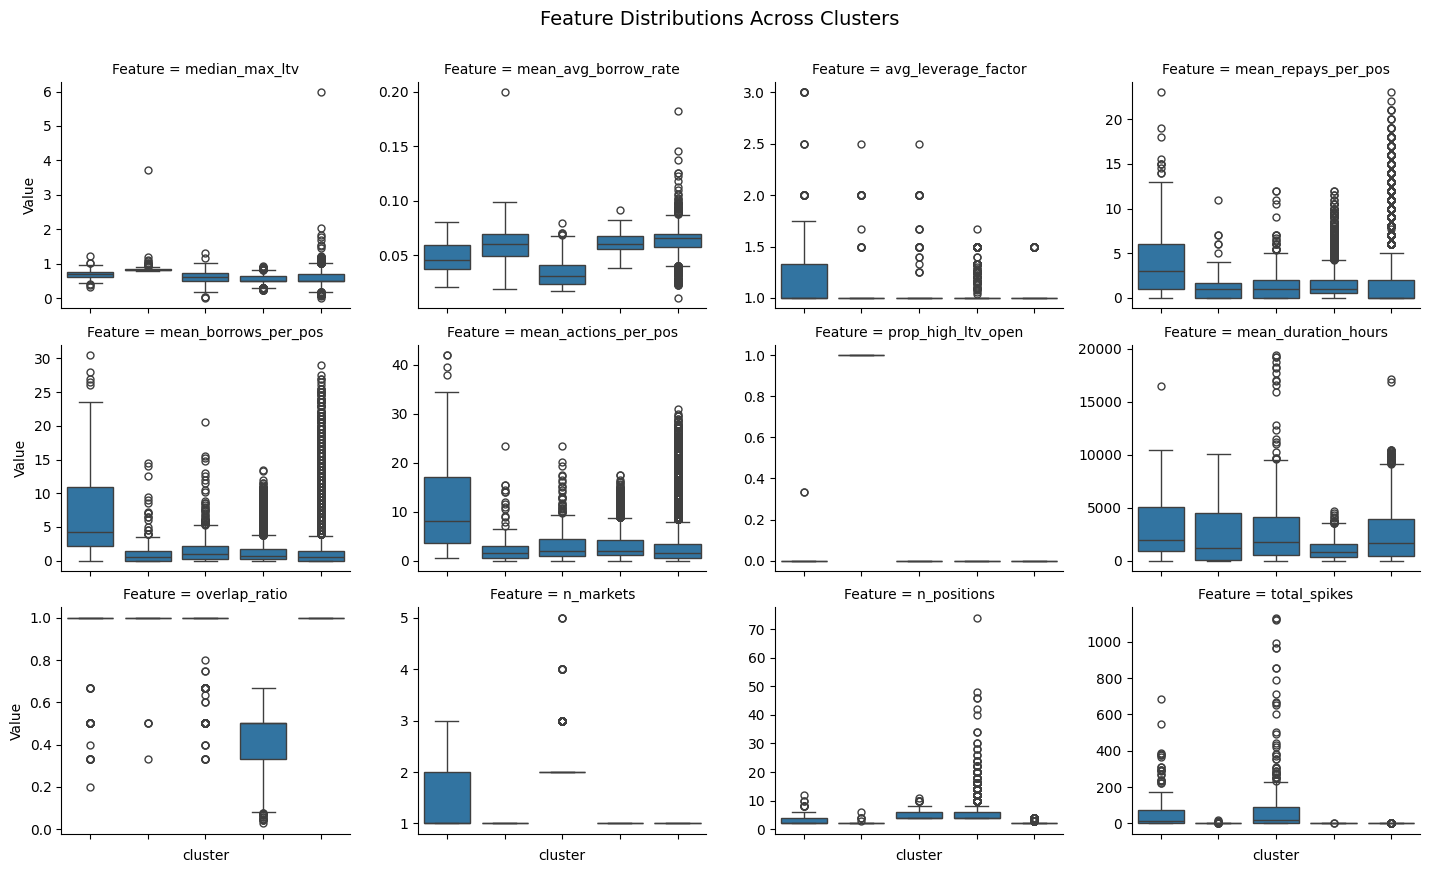

,user_address,n_positions,n_markets,n_collateral_types,n_loan_asset_types,mean_open_debt,median_open_debt,mean_max_debt,median_max_debt,max_debt,median_max_ltv,mean_avg_borrow_rate,mean_duration_hours,median_duration_hours,mean_time_to_first_action,median_time_to_first_action,avg_leverage_factor,mean_repays_per_pos,median_repays_per_pos,total_repays,mean_borrows_per_pos,median_borrows_per_pos,total_borrows,mean_actions_per_pos,median_actions_per_pos,total_actions,mean_avg_repay_ratio,was_active_during_spike_any,debtors_rank_ever,mean_concentration_hhi,total_spikes,prop_closed,prop_high_ltv_open,std_max_ltv,mean_max_share,prop_debtors_rank,mean_utilization_open,mean_total_liquidity_open,mean_effective_close_ltv,median_effective_close_ltv,n_crypto_positions,n_pt_positions,n_yb_positions,has_crypto,has_pt,has_yb,max_concurrent_positions,overlap_ratio,std_avg_borrow_rate,large_max_debt,cluster
1,0x000Aee61aee8aA46422A2f29Ebefc57684A9Ee81,2,1,1,1,200.000000,200.000000,200.000000,200.000000,200.000000,0.644588,0.059911,5128.001111,5128.001111,5128.001111,5128.001111,1.0,1.000000,1.0,2,0.0,0.0,0,1.000000,1.0,2,1.0,False,False,0.700000,0,1.000000,0.0,0.000000,1.324694e-05,0.0,0.855541,2.549292e+06,0.578467,0.578467,0,0,0,False,False,False,2,1.000000,0.000000,False,4
2,0x0012af0486773665A8C99aA1BE743d7c4Ab9c3aC,4,1,1,1,494.750535,494.750535,494.750535,494.750535,934.501070,0.501589,0.068065,1103.829167,1103.829167,1103.829167,1103.829167,1.0,0.500000,0.5,2,0.0,0.0,0,0.500000,0.5,2,1.0,False,False,0.700000,0,0.500000,0.0,0.001347,5.473046e-07,0.0,0.846054,1.597106e+08,0.582371,0.582371,0,0,0,False,False,False,2,0.500000,0.001982,False,3
3,0x001CEb10a85576C67Ec8732F7f39C06fc978F922,2,1,1,1,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,0.693693,0.069873,1095.427778,1095.427778,1095.427778,1095.427778,1.0,0.000000,0.0,0,0.0,0.0,0,0.000000,0.0,0,1.0,False,False,0.700000,0,0.000000,0.0,0.000000,5.027491e-05,0.0,0.874446,1.285163e+08,0.693693,0.693693,0,0,0,False,False,False,2,1.000000,0.000000,False,4
4,0x001D31846d08C23177011C6A523ED5B75823533E,4,2,1,2,37485.929408,37485.929408,47982.168079,47982.168079,49985.007293,0.608000,0.034145,1743.896667,1743.896667,1006.890833,1301.133333,1.0,3.500000,3.5,14,2.5,2.5,10,6.000000,6.0,24,1.0,True,False,0.304165,30,0.500000,0.0,0.031466,9.084929e-03,0.0,0.807007,6.614596e+07,0.608000,0.608000,0,0,0,False,False,False,4,1.000000,0.002740,False,2
5,0x001D862D3ED16aC91233A26fa537509348Da48E5,2,1,1,1,43.000000,43.000000,43.000000,43.000000,43.000000,0.749831,0.069321,924.657222,924.657222,924.657222,924.657222,1.0,1.000000,1.0,2,0.0,0.0,0,1.000000,1.0,2,1.0,False,False,0.700000,0,1.000000,0.0,0.000000,6.010575e-08,0.0,0.895269,8.369044e+07,0.776933,0.776933,0,0,0,False,False,False,2,1.000000,0.000000,False,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30232,0xffb60Fa86eb99C49624B418590C17bAaA3F69fD2,6,1,1,1,2760.435455,2835.180784,4238.435455,2835.180784,8380.125580,0.500335,0.054078,1598.011667,233.257778,1524.474259,78.558889,1.0,4.333333,1.0,26,2.0,0.0,12,6.333333,1.0,38,1.0,False,False,0.700000,0,0.666667,0.0,0.072368,8.972778e-06,0.0,0.878808,3.684390e+07,0.546990,0.500335,0,0,0,False,False,False,2,0.333333,0.006945,False,3
30233,0xffcB5D7d257249aCc2b0Ef3be2aC0d12734C4728,2,1,1,1,105000.000000,105000.000000,105000.000000,105000.000000,105000.000000,0.500572,0.069914,0.055000,0.055000,0.027500,0.027500,1.0,1.000000,1.0,2,0.5,0.5,1,1.500000,1.5,3,1.0,False,False,0.700000,0,1.000000,0.0,0.000000,1.096780e-04,0.0,0.863899,1.508236e+08,0.500195,0.500195,0,0,0,False,False,False,2,1.000000,0.000000,False,4
30234,0xffcC7B2a2571Ec0c7625F854A908347339cac936,2,1,1,1,22140.000000,22140.000000,22140.000000,22140.000000,22140.000000,0.762985,0.070190,1319.779444,1319.779444,1319.779444,1319.779444,1.0,4.000000,4.0,8,0.0,0.0,0,4.000000,4

In [17]:
users_features['large_max_debt'] = users_features['max_debt'] > 1_000_000

evaluate_clustering(
    metrics_hist[120]['labels'],
    X_scaled,
    users_features,
    selected_features,
)

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import f_classif

def interpret_clusters(labels, user_df, feature_names, top_k=10):
    """
    Generate a complete cluster interpretation report.

    Parameters
    ----------
    labels : array-like
        Cluster labels (-1 for noise, if any).
    user_df : pd.DataFrame
        User-level DataFrame containing the features.
    feature_names : list
        Names of the features to analyse (usually the same used for clustering).
    top_k : int
        Number of top important features to highlight.

    Returns
    -------
    importance_df : pd.DataFrame
        Feature importance (ANOVA F‑values).
    cluster_means : pd.DataFrame
        Mean values per cluster.
    zscore_df : pd.DataFrame
        Z‑scores of cluster means relative to global distribution.
    """
    # Convert labels to array and exclude noise
    labels = np.asarray(labels)
    valid_mask = labels != -1
    X = user_df[feature_names].fillna(0).values[valid_mask]
    # print(user_df[feature_names].isna().sum())
    y = labels[valid_mask]

    # 1. Feature importance via ANOVA
    f_vals, p_vals = f_classif(X, y)
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'F_value': f_vals,
        'p_value': p_vals
    }).sort_values('F_value', ascending=False)

    print("="*80)
    print("Top important features (ANOVA F‑value)")
    print(importance_df.head(top_k).to_string(index=False))

    # 2. Cluster means
    df_valid = user_df.iloc[valid_mask].copy()
    df_valid['cluster'] = y
    cluster_means = df_valid.groupby('cluster')[feature_names].mean()
    cluster_medians = df_valid.groupby('cluster')[feature_names].median()

    # 3. Global statistics (only among clustered users, not noise)
    global_mean = df_valid[feature_names].mean()
    global_std = df_valid[feature_names].std()

    # 4. Z‑scores per cluster
    zscore_df = (cluster_means - global_mean) / global_std

    # 5. Heatmap of Z‑scores
    plt.figure(figsize=(14, max(6, len(cluster_means)*1.2)))
    sns.heatmap(zscore_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                linewidths=0.5, cbar_kws={'label': 'Z‑score'})
    plt.title('Cluster Feature Profiles (Z‑scores vs global mean)')
    plt.ylabel('Cluster')
    plt.xlabel('Feature')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # 6. Print cluster summaries for top features
    top_features = importance_df['feature'].head(top_k).tolist()
    print("\n" + "="*80)
    print("Cluster summaries (top features means)")
    for cluster in sorted(cluster_means.index):
        print(f"\n--- Cluster {cluster} (n={df_valid[df_valid['cluster']==cluster].shape[0]}) ---")
        # Show top features for this cluster, highlighting extremes
        for feat in top_features:
            val = cluster_means.loc[cluster, feat]
            z = zscore_df.loc[cluster, feat]
            marker = " **" if abs(z) > 1.5 else ""
            print(f"  {feat:30s}: {val:10.4f}  (z={z:+.2f}){marker}")

    return importance_df, cluster_means, zscore_df



In [188]:
user_clusters_to_save = users_features.copy()[["user_address"]]
user_clusters_to_save['hdbscan_cluster'] = metrics_hist[40]['labels']

user_clusters_to_save.head()
# user_clusters_to_save.to_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/modelling_datasets/users_clusters_mapping.csv", index=False)
user_clusters_to_save['hdbscan_cluster'].value_counts()

hdbscan_cluster
-1    1984
 6    1091
 2     394
 4     360
 1     107
 0      94
 5      70
 3      54
Name: count, dtype: int64

Top important features (ANOVA F‑value)
             feature      F_value       p_value
      large_max_debt          inf  0.000000e+00
  prop_high_ltv_open 4.428747e+06  0.000000e+00
       overlap_ratio 9.547685e+04  0.000000e+00
           n_markets 2.774739e+04  0.000000e+00
         n_positions 6.254328e+03  0.000000e+00
        total_spikes 1.656542e+03  0.000000e+00
      mean_max_share 1.526056e+03  0.000000e+00
mean_avg_borrow_rate 1.486485e+03  0.000000e+00
 avg_leverage_factor 8.650073e+02  0.000000e+00
            max_debt 5.286745e+02  0.000000e+00
 mean_duration_hours 3.387740e+02 6.649921e-285
      median_max_ltv 1.809383e+02 3.108470e-153
mean_actions_per_pos 1.424065e+02 1.156987e-120
mean_borrows_per_pos 1.371235e+02 3.478114e-116
 mean_repays_per_pos 6.097066e+01  2.340140e-51


/Users/yegortrussov/Library/Python/3.9/lib/python/site-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw


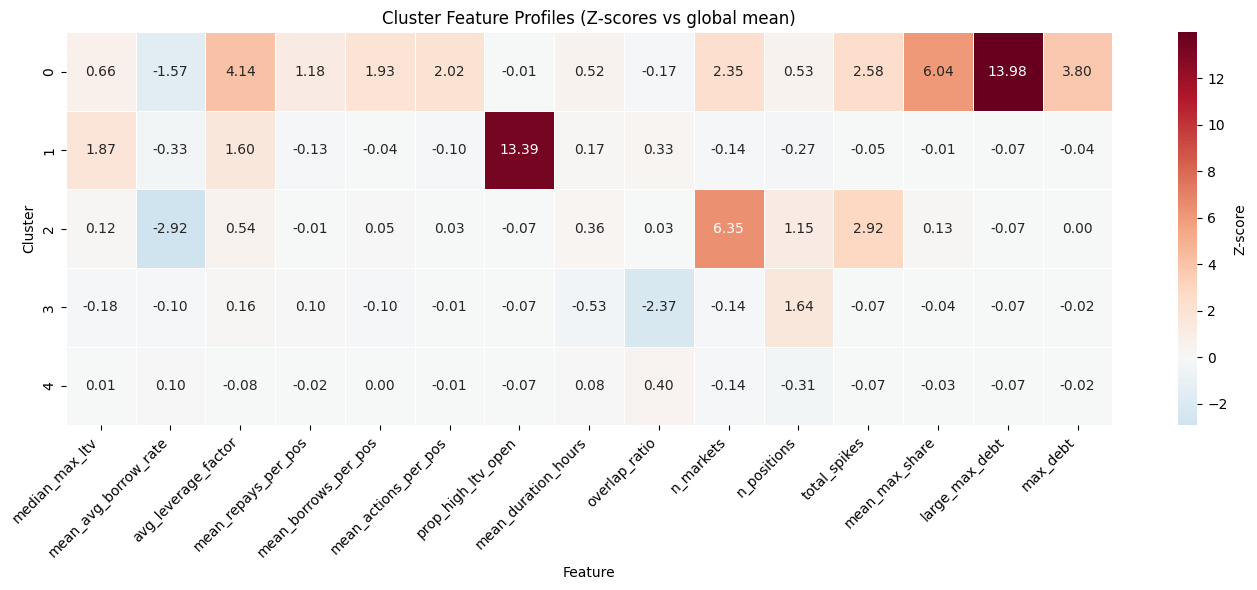


Cluster summaries (top features means)

--- Cluster 0 (n=135) ---
  large_max_debt                :     1.0000  (z=+13.98) **
  prop_high_ltv_open            :     0.0049  (z=-0.01)
  overlap_ratio                 :     0.8798  (z=-0.17)
  n_markets                     :     1.4741  (z=+2.35) **
  n_positions                   :     3.5259  (z=+0.53)
  total_spikes                  :    70.7259  (z=+2.58) **
  mean_max_share                :     0.0439  (z=+6.04) **
  mean_avg_borrow_rate          :     0.0474  (z=-1.57) **
  avg_leverage_factor           :     1.2673  (z=+4.14) **
  max_debt                      : 5446269.5754  (z=+3.80) **
  mean_duration_hours           :  3180.6164  (z=+0.52)
  median_max_ltv                :     0.6891  (z=+0.66)
  mean_actions_per_pos          :    11.6028  (z=+2.02) **
  mean_borrows_per_pos          :     7.2852  (z=+1.93) **
  mean_repays_per_pos           :     4.3175  (z=+1.18)

--- Cluster 1 (n=147) ---
  large_max_debt                :   

In [20]:
users_features['large_max_debt'] = users_features['max_debt'] > 1_000_000
importance_df, cluster_means, zscore_df = interpret_clusters(metrics_hist[120]['labels'], users_features, selected_features, top_k=20)

### **GMM**

In [ ]:
from sklearn.mixture import GaussianMixture
import numpy as np
import pandas as pd

def run_gmm(X_scaled, n_components, covariance_type='full', random_state=42):
    """
    Fit Gaussian Mixture Model and return hard cluster labels.

    Returns
    -------
    labels : np.ndarray
        Integer cluster labels (0 .. n_components-1).
    gmm : GaussianMixture
        Fitted model.
    """
    gmm = GaussianMixture(
        n_components=n_components,
        covariance_type=covariance_type,
        random_state=random_state,
        n_init=5,
        max_iter=200,
        reg_covar=1e-5
    )
    labels = gmm.fit_predict(X_scaled)
    return labels, gmm


def optimize_gmm(X_scaled, 
                 n_components_range=range(2, 15),
                 covariance_types=['full', 'tied', 'diag', 'spherical'],
                 random_state=42):
    """
    Grid search over number of components and covariance type using BIC.
    
    Returns
    -------
    best_labels : np.ndarray
    best_model : GaussianMixture
    results_df : pd.DataFrame
        Table with BIC, AIC, and silhouette for each parameter combination.
    """
    from sklearn.metrics import silhouette_score
    results = []
    best_bic = np.inf
    best_model = None
    best_labels = None
    best_params = None

    for k in tqdm_notebook(n_components_range):
        for cov in covariance_types:
            gmm = GaussianMixture(
                n_components=k,
                covariance_type=cov,
                random_state=random_state,
                n_init=3,          # faster search
                max_iter=150,
                reg_covar=1e-5
            )
            labels = gmm.fit_predict(X_scaled)
            bic = gmm.bic(X_scaled)
            aic = gmm.aic(X_scaled)
            if len(np.unique(labels)) > 1:
                sil = silhouette_score(X_scaled, labels)
            else:
                sil = -1
            results.append({
                'n_components': k,
                'covariance_type': cov,
                'BIC': bic,
                'AIC': aic,
                'Silhouette': sil
            })
            if bic < best_bic:
                best_bic = bic
                best_model = gmm
                best_labels = labels
                best_params = (k, cov)
    
    results_df = pd.DataFrame(results).sort_values('BIC')
    print(f"Best parameters: n_components={best_params[0]}, covariance_type={best_params[1]}")
    print(f"Best BIC = {best_bic:.2f}")
    return best_labels, best_model, results_df


In [25]:
# gmm_labels, gmm_clusterer = run_gmm(X_scaled, 8, covariance_type='diag')
gmm_labels, best_gmm_model, gmm_results_df = optimize_gmm(X_scaled, n_components_range=(5, 6, 7, 8), covariance_types=['diag'])

Best parameters: n_components=8, covariance_type=diag
Best BIC = -1479363.04


In [26]:
gmm_results_df

,n_components,covariance_type,BIC,AIC,Silhouette
3,8,diag,-1.479363e+06,-1.481417e+06,0.167697
2,7,diag,-1.434959e+06,-1.436755e+06,0.158740
1,6,diag,-1.298144e+06,-1.299683e+06,0.285264
0,5,diag,-1.257083e+06,-1.258364e+06,0.280186


In [50]:
calc_clustering_quality(gmm_labels, X_scaled)

{'n_clusters': 10,
 'noise_ratio': 0.0,
 'silhouette': 0.24898281173957054,
 'davies_bouldin': 1.5754946763691624,
 'calinski_harabasz': 561.2970340082433}

HDBSCAN Clustering Evaluation
  Number of clusters (excluding noise): 10
  Noise points: 0 (0.0%)
  Cluster sizes:
    Cluster 0: 550 users (13.2%)
    Cluster 1: 1049 users (25.3%)
    Cluster 2: 91 users (2.2%)
    Cluster 3: 763 users (18.4%)
    Cluster 4: 203 users (4.9%)
    Cluster 5: 122 users (2.9%)
    Cluster 6: 484 users (11.7%)
    Cluster 7: 56 users (1.3%)
    Cluster 8: 719 users (17.3%)
    Cluster 9: 117 users (2.8%)
  Silhouette Score (core): 0.2490
  Davies-Bouldin Score (core): 1.5755
  Calinski-Harabasz Score (core): 561.30


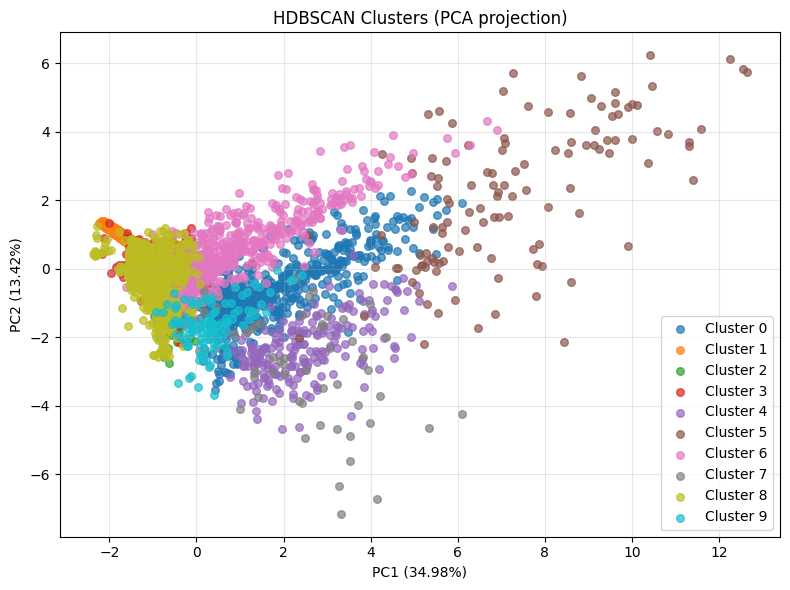

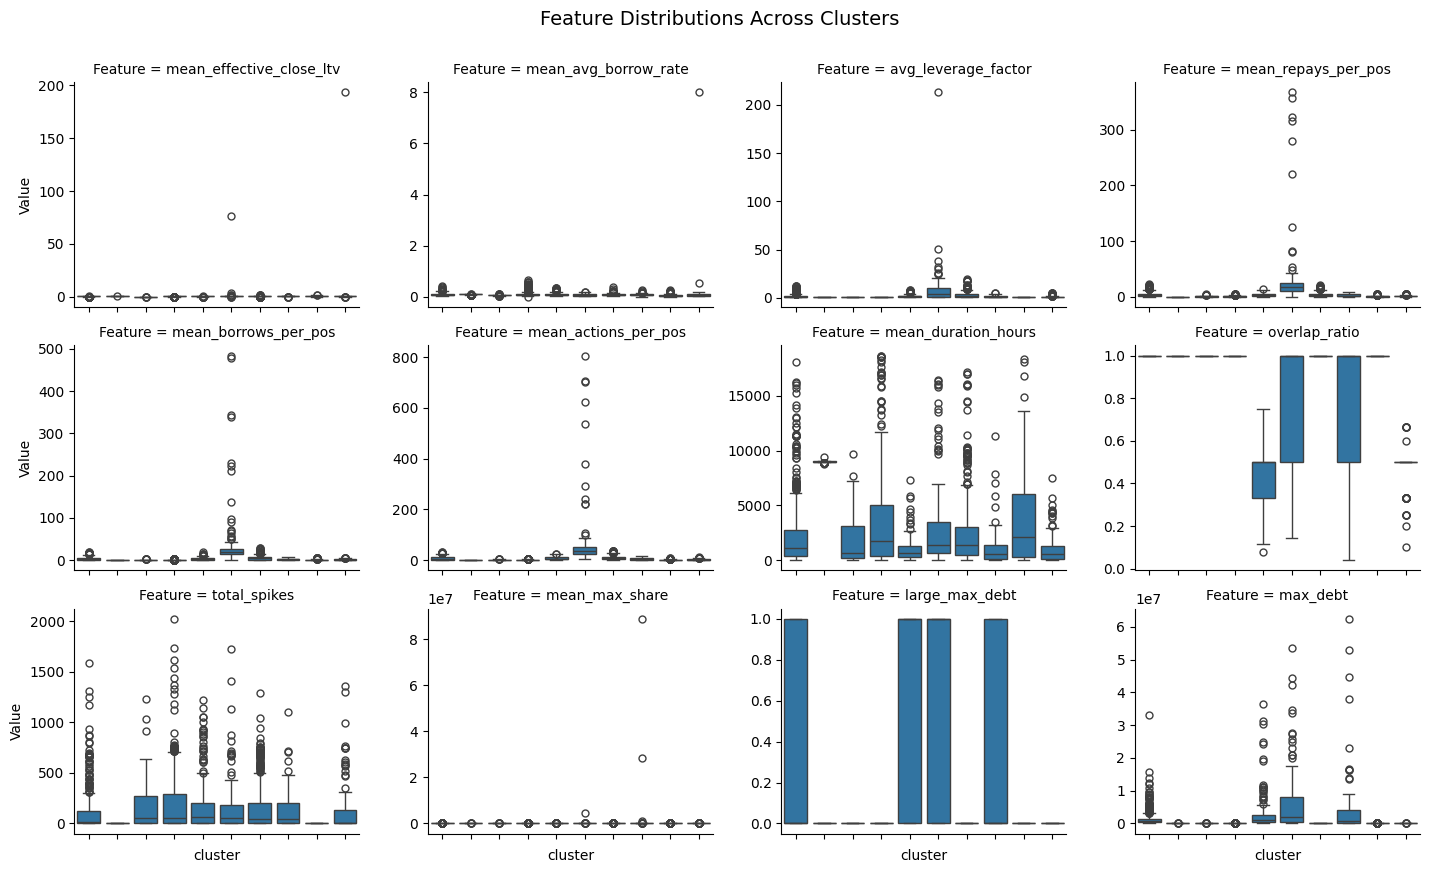

,user_address,n_positions,n_markets,n_collateral_types,n_loan_asset_types,mean_open_debt,median_open_debt,mean_max_debt,median_max_debt,max_debt,median_max_ltv,mean_avg_borrow_rate,mean_duration_hours,median_duration_hours,mean_time_to_first_action,median_time_to_first_action,avg_leverage_factor,mean_repays_per_pos,median_repays_per_pos,total_repays,mean_borrows_per_pos,median_borrows_per_pos,total_borrows,mean_actions_per_pos,median_actions_per_pos,total_actions,mean_avg_repay_ratio,was_active_during_spike_any,debtors_rank_ever,mean_concentration_hhi,total_spikes,prop_closed,prop_high_ltv_open,std_max_ltv,mean_max_share,prop_debtors_rank,mean_utilization_open,mean_total_liquidity_open,mean_effective_close_ltv,median_effective_close_ltv,n_crypto_positions,n_pt_positions,n_yb_positions,has_crypto,has_pt,has_yb,max_concurrent_positions,overlap_ratio,std_avg_borrow_rate,large_max_debt,cluster
0,0x00000000F51340906F767C6999Fe512b1275955C,2,1,1,1,4.998528,4.998528,4.998528,4.998528,4.998528e+00,0.469664,0.083713,0.620000,0.620000,0.310000,0.310000,1.00,1.00,1.0,2,0.50,0.5,1,1.50,1.5,3,1.0,False,False,3.103588,0,1.0,0.00,0.000000,3.531609e-06,0.00,0.896690,1.630675e+05,0.469664,0.469664,0,0,0,False,False,False,2,1.00,0.000000,False,8
1,0x000001ac4e512d670c34feDf6c71cE2F49fb160a,100,3,3,1,153781.904797,102098.191037,421450.969498,177223.440043,2.471676e+06,0.865724,0.100561,6.212600,3.570000,1.147348,0.073333,3.01,1.52,1.0,152,2.02,1.0,202,3.54,2.0,354,1.0,True,True,97.662618,94,1.0,0.98,0.024388,3.984192e-01,0.22,0.784073,6.796433e+06,0.839247,0.859144,0,0,0,False,False,False,4,0.04,0.069396,True,7
2,0x00000655388D579492CF53ca6F490EaA30711112,2,1,1,1,7982.541842,7982.541842,34290.845308,34290.845308,3.429085e+04,0.844130,0.088254,142.410000,142.410000,0.031667,0.031667,1.00,5.00,5.0,10,4.50,4.5,9,9.50,9.5,19,1.0,True,False,0.163256,40,1.0,1.00,0.000000,1.070827e-03,0.00,0.913085,2.679104e+06,0.801267,0.801267,0,0,0,False,False,False,2,1.00,0.000000,False,6
3,0x00000F91109c4d0007e90000D9facAD5298A0CAc,2,1,1,1,521.323912,521.323912,14642.535854,14642.535854,1.464254e+04,0.858971,0.050472,301.563333,301.563333,301.563333,301.563333,17.00,1.00,1.0,2,19.00,19.0,38,20.00,20.0,40,1.0,True,False,1.533227,14,0.0,1.00,0.000000,6.887748e-03,0.00,0.729259,7.892433e+05,0.858971,0.858971,0,0,0,False,False,False,2,1.00,0.000000,False,6
4,0x00042A6D544e57aC524ef1d26e870E2FB75a58E3,2,1,1,1,9.998358,9.998358,9.998358,9.998358,9.998358e+00,0.428531,0.038830,8.916667,8.916667,8.630000,8.630000,1.00,1.00,1.0,2,0.00,0.0,0,1.00,1.0,2,1.0,False,False,0.251156,0,1.0,0.00,0.000000,1.827595e-07,0.00,0.895672,6.372342e+06,0.428531,0.428531,0,0,0,False,False,False,2,1.00,0.000000,False,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4149,0xfe6b6EF4C9358af544768B60cDF80B78dAE20818,2,1,1,1,265813.185562,265813.185562,468502.403742,468502.403742,4.685024e+05,0.571208,0.066268,6656.173333,6656.173333,325.451667,325.451667,1.00,1.00,1.0,2,4.50,4.5,9,5.50,5.5,11,1.0,True,False,0.363138,6,1.0,0.00,0.000000,1.092555e-02,0.00,0.823789,1.034209e+07,0.687555,0.687555,0,0,0,False,False,False,2,1.00,0.000000,False,0
4150,0xfe7c0Af3D0C6D6974bf76120A2A72c1d32c13DE5,2,1,1,1,299951.700000,299951.700000,499904.500000,499904.500000,4.999045e+05,0.699435,0.045209,4582.033333,4582.033333,4582.033333,4582.033333,1.00,3.00,3.0,6,2.00,2.0,4,5.00,5.0,10,1.0,False,False,0.341564,0,0.0,0.00,0.000000,8.362928e-03,0.00,0.806365,1.382424e+07,0.699435,0.699435,0,0,0,False,False,False,2,1.00,0.000000,False,0
4151,0xfee1720f1e4688b58b60309972d85272DE95Db34,2,1,1,1,41000.000000,41000.000000,44978.310000,44978.310000,4.497831e+04,0.561893,0.055619,795.006667,795.006667,396.268333,396.268333,1.00,1.00,1.0,2,1.50,1.5,3,2.50,2.5,5,1.0,False,False,0.471187,0,1.0,0.00,0.000000,1.272189e-03,0.00,0.901417,2.034426e+06,0.561893,0.561893,0,0,0,F

In [53]:
evaluate_clustering(
    gmm_labels,
    X_scaled,
    users_features,
    selected_features,
)

Top important features (ANOVA F‑value)
                 feature     F_value       p_value
           overlap_ratio 2455.910220  0.000000e+00
     mean_duration_hours  411.178714  0.000000e+00
          large_max_debt  291.251687  0.000000e+00
                max_debt  127.956105 3.694060e-213
    mean_actions_per_pos  127.451318 2.163360e-212
    mean_borrows_per_pos  114.481686 1.906907e-192
     mean_repays_per_pos  108.673652 2.257251e-183
            total_spikes   90.872746 5.320608e-155
     avg_leverage_factor   65.974500 7.870508e-114
          mean_max_share   13.372868  2.418075e-21
    mean_avg_borrow_rate    8.409296  1.534920e-12
mean_effective_close_ltv    4.509941  6.360090e-06


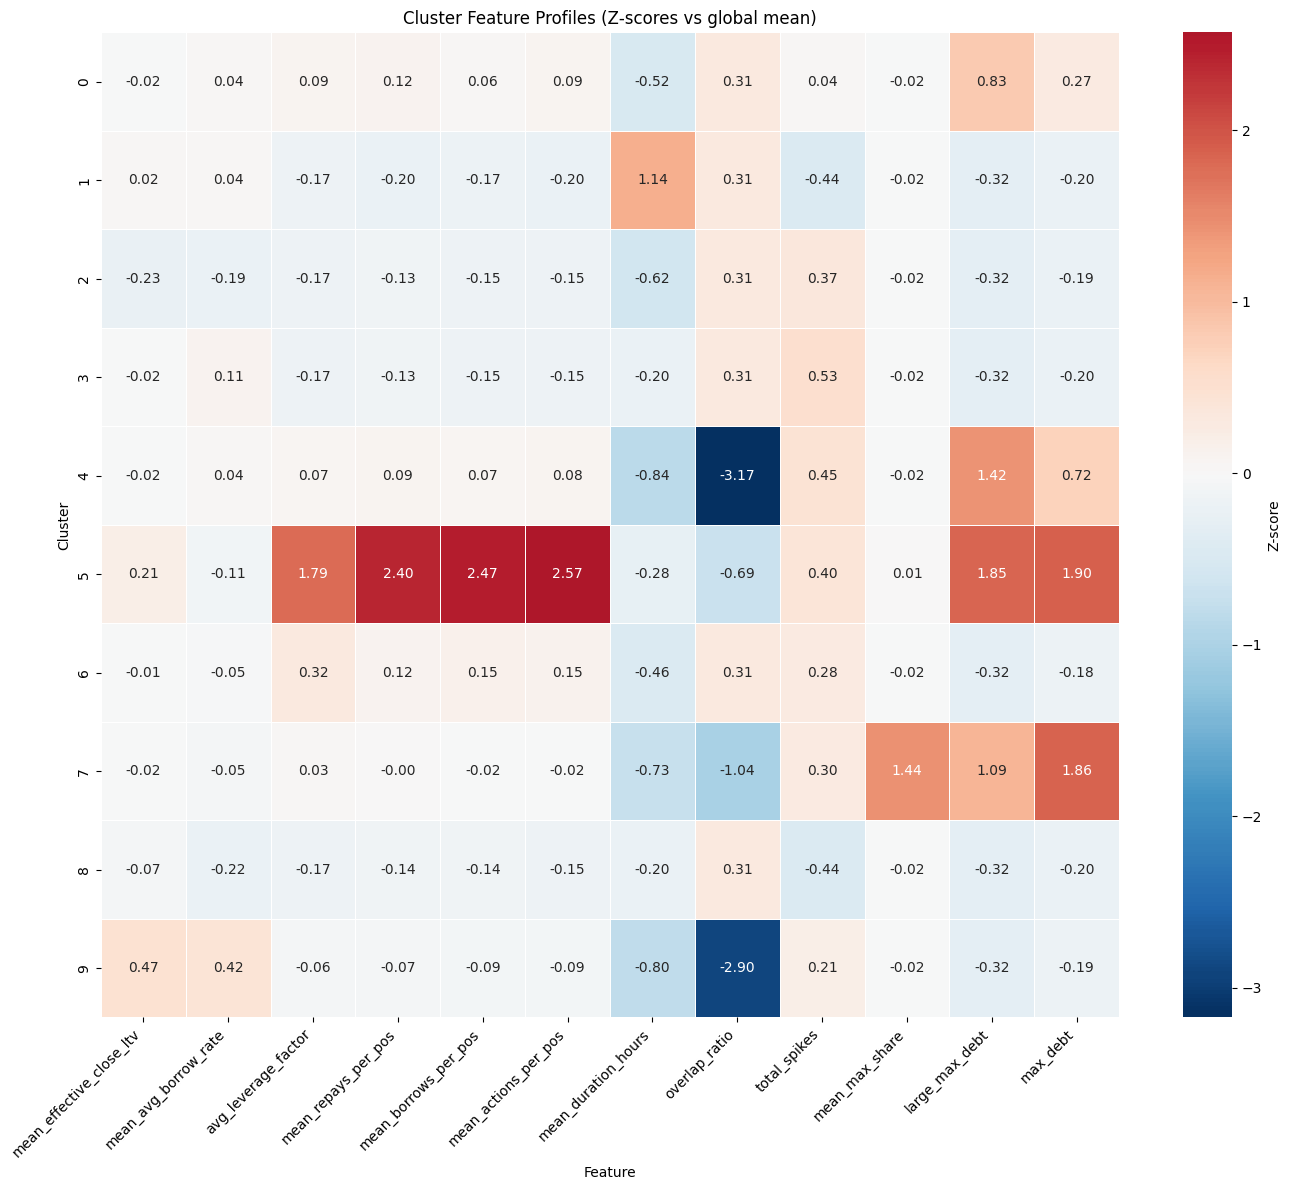


Cluster summaries (top features means)

--- Cluster 0 (n=550) ---
  overlap_ratio                 :     1.0000  (z=+0.31)
  mean_duration_hours           :  2239.6713  (z=-0.52)
  large_max_debt                :     0.3364  (z=+0.83)
  max_debt                      : 1456974.4915  (z=+0.27)
  mean_actions_per_pos          :     7.9195  (z=+0.09)
  mean_borrows_per_pos          :     3.7014  (z=+0.06)
  mean_repays_per_pos           :     4.2180  (z=+0.12)
  total_spikes                  :    99.6582  (z=+0.04)
  avg_leverage_factor           :     2.0252  (z=+0.09)
  mean_max_share                :     0.0331  (z=-0.02)
  mean_avg_borrow_rate          :     0.1000  (z=+0.04)
  mean_effective_close_ltv      :     0.6877  (z=-0.02)

--- Cluster 1 (n=1049) ---
  overlap_ratio                 :     1.0000  (z=+0.31)
  mean_duration_hours           :  9011.6770  (z=+1.14)
  large_max_debt                :     0.0000  (z=-0.32)
  max_debt                      :     0.3400  (z=-0.20)
  mean_

In [51]:
importance_df, cluster_means, zscore_df = interpret_clusters(gmm_labels, users_features, selected_features, top_k=20)

HDBSCAN Clustering Evaluation
  Number of clusters (excluding noise): 8
  Noise points: 0 (0.0%)
  Cluster sizes:
    Cluster 0: 609 users (37.5%)
    Cluster 1: 42 users (2.6%)
    Cluster 2: 77 users (4.7%)
    Cluster 3: 73 users (4.5%)
    Cluster 4: 154 users (9.5%)
    Cluster 5: 153 users (9.4%)
    Cluster 6: 141 users (8.7%)
    Cluster 7: 373 users (23.0%)
  Silhouette Score (core): 0.1336
  Davies-Bouldin Score (core): 2.1335
  Calinski-Harabasz Score (core): 147.56


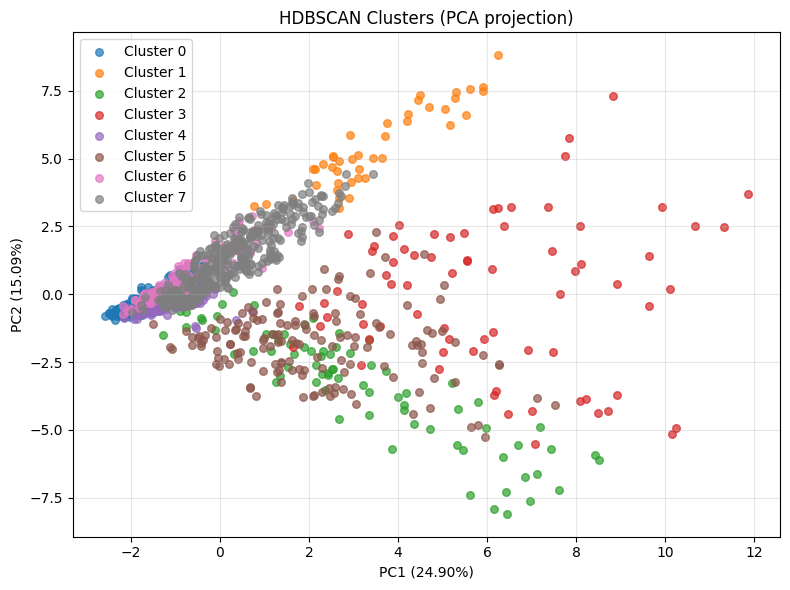

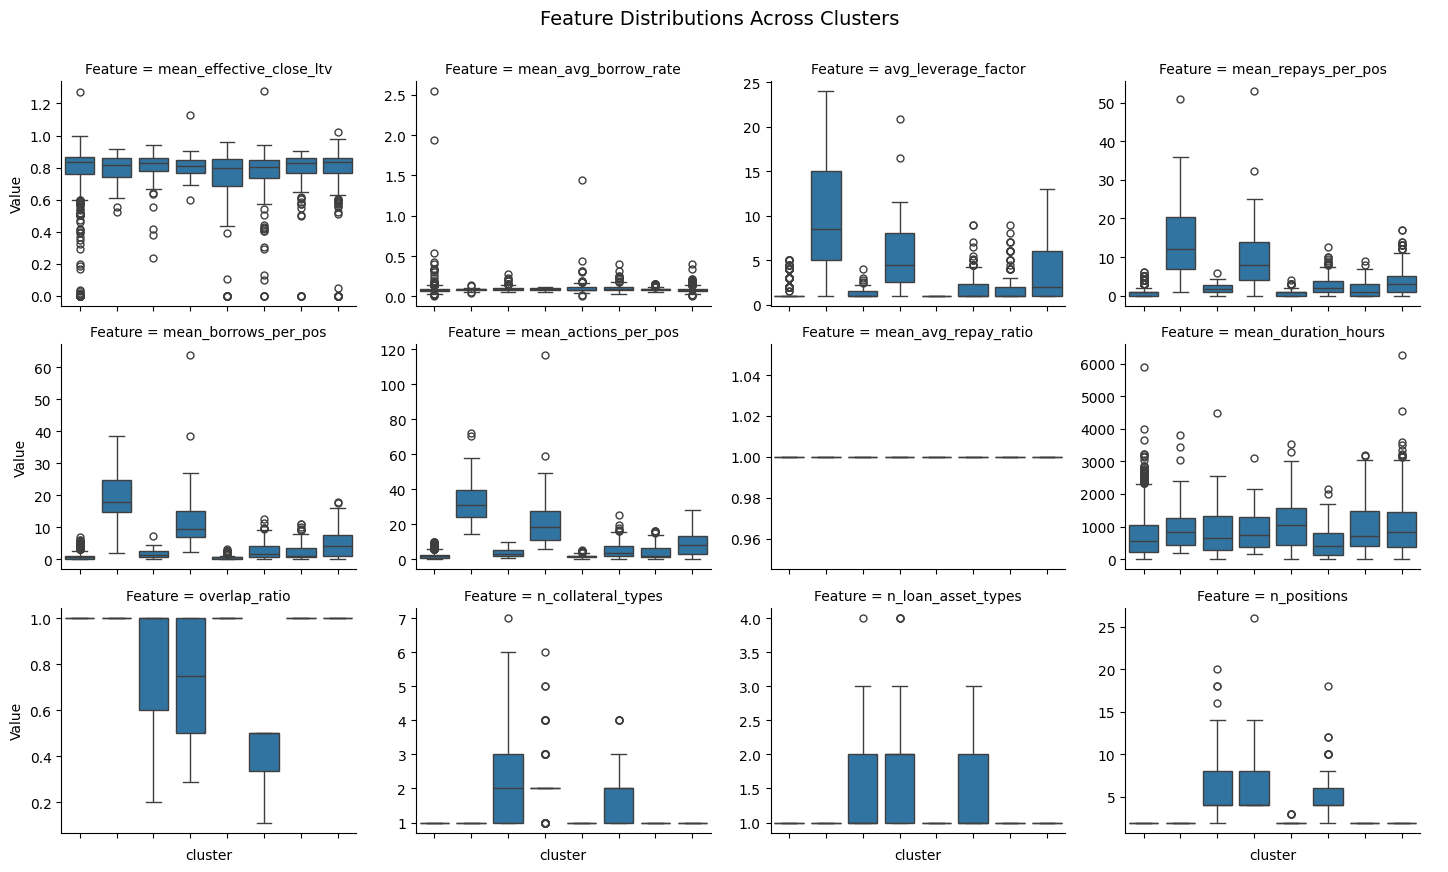

,user_address,n_positions,n_markets,n_collateral_types,n_loan_asset_types,mean_open_debt,median_open_debt,mean_max_debt,median_max_debt,max_debt,median_max_ltv,mean_avg_borrow_rate,mean_duration_hours,median_duration_hours,mean_time_to_first_action,median_time_to_first_action,avg_leverage_factor,mean_repays_per_pos,median_repays_per_pos,total_repays,mean_borrows_per_pos,median_borrows_per_pos,total_borrows,mean_actions_per_pos,median_actions_per_pos,total_actions,mean_avg_repay_ratio,was_active_during_spike_any,debtors_rank_ever,mean_concentration_hhi,total_spikes,prop_closed,prop_high_ltv_open,std_max_ltv,mean_max_share,prop_debtors_rank,mean_utilization_open,mean_total_liquidity_open,mean_days_to_expiry,median_days_to_expiry,prop_closed_near_expiry,prop_opened_early,n_yb_tokens,mean_effective_close_ltv,median_effective_close_ltv,max_concurrent_positions,overlap_ratio,std_avg_borrow_rate,large_max_debt,cluster
0,0x002AFa1e35cE85272aAE5e0d7Ab541DFd442B667,2,1,1,1,1.579708e+04,1.579708e+04,1.579708e+04,1.579708e+04,1.579708e+04,0.851547,0.099236,662.270000,662.270000,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,True,False,0.307859,36.0,1.0,1.0,0.0,0.000077,0.0,0.890883,2.527534e+07,9.0,9.0,0.0,0.0,1,0.843812,0.843812,2,1.0,0.0,False,0
1,0x00896485a15c549AA6948c7430bef1f02f752300,2,1,1,1,1.599523e+04,1.599523e+04,1.599523e+04,1.599523e+04,1.599523e+04,0.804415,0.094134,297.676667,297.676667,143.663333,143.663333,1.0,1.0,1.0,2.0,0.5,0.5,1.0,1.5,1.5,3.0,1.0,False,False,0.700000,0.0,1.0,0.0,0.0,0.070776,0.0,0.918699,2.000004e+04,50.0,50.0,0.0,1.0,1,0.803997,0.803997,2,1.0,0.0,False,4
2,0x008E5d9ea233Dfb9AB48098d6E98E14374030c15,2,1,1,1,1.689294e+05,1.689294e+05,9.847084e+05,9.847084e+05,9.847084e+05,0.857420,0.057556,1837.820000,1837.820000,0.045000,0.045000,14.0,29.0,29.0,58.0,14.5,14.5,29.0,43.5,43.5,87.0,1.0,True,True,1.000000,54.0,1.0,1.0,0.0,0.622500,1.0,0.696064,7.598600e+06,-1.0,-1.0,0.0,0.0,1,0.628643,0.628643,2,1.0,0.0,False,1
3,0x00A2913501C4B09B92b825dC8A2937eFDaD9953b,2,1,1,1,4.999480e+05,4.999480e+05,7.298244e+06,7.298244e+06,7.298244e+06,0.797200,0.145384,1755.310000,1755.310000,10.883333,10.883333,1.0,8.0,8.0,16.0,8.0,8.0,16.0,16.0,16.0,32.0,1.0,True,True,1.000002,154.0,1.0,0.0,0.0,0.498799,1.0,0.934287,9.279599e+05,-2.0,-2.0,0.0,1.0,1,0.718067,0.718067,2,1.0,0.0,True,7
4,0x00B8dF76c223eb4b05123389330b4afD157152b8,2,1,1,1,1.238581e+06,1.238581e+06,4.760966e+06,4.760966e+06,4.760966e+06,0.890971,0.052546,437.876667,437.876667,0.076667,0.076667,4.0,5.0,5.0,10.0,4.5,4.5,9.0,9.5,9.5,19.0,1.0,True,True,0.688498,20.0,1.0,1.0,0.0,1.741203,1.0,0.368415,4.687495e+06,-1.0,-1.0,0.0,0.0,1,0.854283,0.854283,2,1.0,0.0,True,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1617,0xfc9803f19a667Ac43E13fC57405f9fDCdaC54747,2,1,1,1,1.299721e+04,1.299721e+04,1.499973e+04,1.499973e+04,1.499973e+04,1.272642,0.075387,387.983333,387.983333,248.103333,248.103333,1.0,1.0,1.0,2.0,2.0,2.0,4.0,3.0,3.0,6.0,1.0,True,False,0.616618,16.0,1.0,1.0,0.0,0.002204,0.0,0.891826,8.900126e+05,NaN,NaN,0.0,0.0,1,1.272642,1.272642,2,1.0,0.0,False,0
1618,0xfcB2f00cF544E934E2f163c2593c7CE3eF7fFA9D,2,1,1,1,1.399968e+05,1.399968e+05,1.399968e+05,1.399968e+05,1.399968e+05,0.867930,0.061129,132.886667,132.886667,66.413333,66.413333,1.0,2.0,2.0,4.0,0.5,0.5,1.0,2.5,2.5,5.0,1.0,True,True,0.949284,16.0,1.0,1.0,0.0,0.317168,1.0,0.867609,6.735403e+04,135.0,135.0,0.0,0.0,1,0.867930,0.867930,2,1.0,0.0,False,7
1619,0xfd1fA2C22F65649AE02188a33F286f22bcFCd225,2,1,1,1,4.490104e+04,4.490104e+04,9.136159e+04,9.136159e+04,9.136159e+04,0.903065,0.170632,695.083333,695.083333,17.473333,17.473333,1.0,0.0,0.0,0.0,1.5,1.5,3.0,1.5,1.5,3.0,1.0,True,False,0.850482,16.0,1.0,1.0,0.0,0.001948,0.0,0.850424,7.803732e+06,66.0,66.0,0.0,0.0,1,0.883420,0.883420,2,1.0,0.0,False,0
1620,0xff17d5A9f7dB38A1384CF0ce1c81b880D17dB838,2,1,1,1,5.29

In [50]:
evaluate_clustering(gmm_labels, X_scaled, users_features, selected_features)

### **Cluster users analisys**

In [195]:
df_with_clusters = df.merge(user_clusters_to_save[["user_address", "hdbscan_cluster"]], how='left', on='user_address') \
    .rename(columns={"hdbscan_cluster": "cluster"})
df_with_clusters['market_type'] = df_with_clusters.apply(lambda r : "crypto" if r['market'] in CRYPTO_MARKETS else ("yb" if r['market'] in YB_TOKENS else 'pt'), axis=1)
df_with_clusters.head(3)

,user_address,market,open_timestamp,open_datetime,open_debt,open_ltv,open_borrow_rate,leverage_factor,close_timestamp,close_datetime,close_debt,close_ltv,close_borrow_rate,max_debt,max_ltv,n_repays,n_borrows,is_closed,duration_hours,time_to_first_action,avg_time_between_actions,max_time_between_actions,n_actions_total,avg_repay_ratio,was_active_during_spike,num_spikes_experienced,closed_during_spike,position_size_share_open,position_size_share_max,debtors_rank,utilization_open,total_debt_open,total_liquidity_open,concentration_hhi_open,top3_share_open,avg_borrow_rate_position,position_index,collateral_asset,loan_asset,cluster,market_type
0,0xf8b9D83574574A345c32905a2A62D1d84650A0Ae,base_cbbtc_usdc_full,1726217705,2024-09-13 08:55:05,1.0,0.172022,0.041709,1,1.764177e+09,2025-11-26 17:05:11,1.000000,0.172022,0.041709,1.0,0.172022,0,0,False,10544.168333,10544.168333,10544.168333,10544.168333,0,1,False,0,False,NaN,NaN,False,0.000000,0.0,0.000000,NaN,NaN,0.041709,0,cbbtc,usdc,-1,crypto
1,0xf8b9D83574574A345c32905a2A62D1d84650A0Ae,base_cbbtc_usdc_full,1726217705,2024-09-13 08:55:05,1.0,0.172022,0.041709,1,1.764177e+09,2025-11-26 17:05:11,1.000000,0.172022,0.041709,1.0,0.172022,0,0,False,10544.168333,10544.168333,10544.168333,10544.168333,0,1,False,0,False,NaN,NaN,False,0.000000,0.0,0.000000,NaN,NaN,0.041709,1,cbbtc,usdc,-1,crypto
2,0x9aE9A52Eb952aE82c592e109f04C844B94e9975a,base_cbbtc_usdc_full,1726241775,2024-09-13 15:36:15,150000.0,0.700799,0.041616,1,1.727133e+09,2024-09-23 23:02:29,-8.357457,-0.231041,0.026968,150000.0,0.700799,3,0,True,247.437222,12.058889,98.025000,195.958889,3,1,False,0,False,150000.0,150000.0,False,0.983789,1.0,0.016478,NaN,NaN,0.030925,2,cbbtc,usdc,-1,crypto


In [159]:
df_with_clusters.shape, df.shape

((109479, 40), (109479, 39))

In [198]:
for c in sorted(df_with_clusters['cluster'].unique()):
    cl_users = df_with_clusters[df_with_clusters['cluster'] == c]
    print(f"{c} - {cl_users['market_type'].value_counts().to_dict()}")

-1 - {'crypto': 11972, 'yb': 5758, 'pt': 2824}
0 - {'crypto': 902, 'yb': 138, 'pt': 48}
1 - {'pt': 200, 'yb': 136, 'crypto': 28}
2 - {'crypto': 1036}
3 - {'pt': 568, 'yb': 500, 'crypto': 8}
4 - {'yb': 2142, 'crypto': 92, 'pt': 28}
5 - {'crypto': 694, 'yb': 464, 'pt': 200}
6 - {'crypto': 24958, 'yb': 76, 'pt': 6}
7 - {'crypto': 31170, 'yb': 458, 'pt': 20}
8 - {'crypto': 12500, 'yb': 370, 'pt': 26}


In [202]:
for m in df_with_clusters['market_type'].unique():
    cl_users = df_with_clusters[df_with_clusters['market_type'] == m]
    print(f"{m} - {cl_users['cluster'].value_counts().sort_index().to_dict()}")

crypto - {-1: 11972, 0: 902, 1: 28, 2: 1036, 3: 8, 4: 92, 5: 694, 6: 24958, 7: 31170, 8: 12500}
pt - {-1: 2824, 0: 48, 1: 200, 3: 568, 4: 28, 5: 200, 6: 6, 7: 20, 8: 26}
yb - {-1: 5758, 0: 138, 1: 136, 3: 500, 4: 2142, 5: 464, 6: 76, 7: 458, 8: 370}


In [206]:
cl_users = df_with_clusters[df_with_clusters['cluster']==3]
# df_with_clusters[df_with_clusters['cluster']==1]['user_address'].nunique(), df_with_clusters[df_with_clusters['cluster']==1].shape
cl_users['max_debt'].describe()

cl_users[[
    'user_address',
    "market",
    "max_debt",
    "open_ltv",
    "close_ltv",
    "duration_hours",
    "was_active_during_spike",
]]

,user_address,market,max_debt,open_ltv,close_ltv,duration_hours,was_active_during_spike
77386,0x00e9eaF42eD86610Df9510d123Cf4d7a5D19FAd4,eth_cbbtc_usdc,69499.305000,0.823325,0.666573,4512.090000,True
77387,0x00e9eaF42eD86610Df9510d123Cf4d7a5D19FAd4,eth_cbbtc_usdc,69499.305000,0.823325,0.666573,4512.090000,True
77544,0x38ac78C059314F933DC7Bd348Fc1E7F11c33c002,eth_cbbtc_usdc,8192.385548,0.819027,0.819027,7959.403333,True
77545,0x38ac78C059314F933DC7Bd348Fc1E7F11c33c002,eth_cbbtc_usdc,8192.385548,0.819027,0.819027,7959.350000,True
79068,0x0cFaEc112c30A5A392eb633daAe5231Aa3d7623F,eth_wbtc_usdc,11011.000000,0.805381,0.735788,2471.213333,True
...,...,...,...,...,...,...,...
97249,0x1E6315Ba6AfD1B04f9c1A1629517BEA60449e7C3,eth_wstusr_usdc,222779.840179,0.867569,0.864510,136.190000,True
97254,0x4fe8810d083ca126D65A9397d462b824AA6Ab799,eth_wstusr_usdc,176327.643213,0.857941,0.000000,102.436667,True
97255,0x4fe8810d083ca126D65A9397d462b824AA6Ab799,eth_wstusr_usdc,176327.643213,0.857941,0.000000,102.436667,True
97276,0xd529b4Bdd387f6dc09008244a9d86ACC2FF7718C,eth_wstusr_usdc,21493.765000,0.859266,0.850811,771.656667,True


In [207]:
cl_users['market'].value_counts()

market
eth_usr_usdc                       130
eth_slvlusd_usdc                   124
eth_PT-csUSDL-31JUL2025_usdc       102
eth_PT-USDe-25SEP2025_usdc          66
eth_wstusr_usdc                     64
eth_PT-stcUSD-29JAN2026_usdc        58
eth_PT-USDe-25SEP2025_usdt          52
eth_PT-lvlUSD-29MAY2025_usdc        46
eth_PT-slvlUSD-25SEP2025_usdc       42
eth_rlp_usdc                        40
eth_mhyper_usdc                     38
eth_PT-wstUSR-27MAR2025_usr         36
eth_usd0++_usdc                     32
eth_PT-wstUSR-25SEP2025_usdc        30
eth_PT-USDe-31JUL2025_dai           30
eth_PT-RLP-4SEP2025_usdc            26
eth_csusdl_usdc                     20
eth_PT-mHYPER-20NOV2025_usdc        18
eth_fxsave_usdc                     18
eth_siusd_usdc                      14
eth_PT-USDe-27MAR2025_dai           14
eth_PT-slvlUSD-29MAY2025_usdc       12
eth_PT-USDe-27NOV2025_usds          10
eth_syrupusdc_usdc                   8
eth_PT-USD0++-27MAR2025_usdc         8
eth_usde_dai      

In [ ]:
susp_opens = df.groupby(["user_address", "open_timestamp", "market"])['open_debt'].count()
susp_opens[susp_opens > 2].reset_index()['market'].value_counts()
susp_opens.value_counts()

open_debt
2     48245
1      1068
11     1028
3       125
4        50
19        2
Name: count, dtype: int64

market
eth_PT-reUSD-25JUN2026_usdc        1025
base_cbbtc_usdc_full                 82
base_wbtc_usdt                       15
eth_wbtc_usdt                        15
eth_wbtc_usdc                        10
eth_wsteth_usdc                       9
eth_PT-USD0++-27MAR2025_usdc          6
eth_wsteth_usdt                       6
eth_weth_usdt                         5
eth_usd0++_usdc                       5
eth_PT-sNUSD-5MAR2026_usdc            5
eth_cbbtc_usdc                        3
eth_usde_dai                          3
eth_PT-USDe-25SEP2025_dai             2
eth_PT-RLP-4SEP2025_usdc              2
eth_PT-wstUSR-25SEP2025_usdc          2
eth_susde_pyusd                       2
eth_PT-syrupUSDC-28AUG2025_usdc       2
eth_wstusr_usdc                       1
eth_rlp_usdc                          1
eth_PT-USDe-25SEP2025_usdc            1
eth_usr_usdc                          1
eth_PT-slvlUSD-25SEP2025_usdc         1
eth_PT-slvlUSD-29MAY2025_usdc         1
Name: count, dtype: int64